In [1]:
import time
import os
import gc
import math
import cv2
import numpy as np
import pandas as pd
import pyautogui as pa
import shutil
import re  # regex
from PIL import Image, ImageDraw
import random
from scipy.stats import sem, ttest_ind, norm, ttest_ind_from_stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import imageio
from sklearn.cluster import KMeans

from lib.analysis.trace_metrics import TraceMetrics
from lib.analysis.false_discovery_control import false_discovery_control
from lib.auto_GUI.auto_PhotoZ import AutoPhotoZ
from lib.analysis.laminar_dist import *
from lib.analysis.align import ImageAlign
from lib.file.ROI_writer import ROIFileWriter
from lib.analysis.barrel_roi import Barrel_ROI_Creator
from lib.analysis.cell_roi import RandomROISample, OverlapCounterROI
from lib.analysis.baseline_correction import BaselineCorrection

# 2-way ANOVA for medial and lateral PPR vs IPI
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from lib.utilities import *
from lib.file.TIF import *

from ZDA_Adventure.utility import ROIFileReader

import networkx as nx
from skimage.measure import label, regionprops
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import hashlib

try:
    from PPR_PV_anna_Dec2025_progress import rec_id_skip_list
except ImportError:
    rec_id_skip_list = []


In [ ]:
# Load data, not from Drive for Desktop since PhotoZ complains about loading zda from Drive
data_dir = "C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/"
camera_program = 4
which_rig = 'old'  # change to 'old' for old rig dic alignment
date_format = 'yy-mm-dd'
if which_rig == 'old':
    date_format = 'yyyy-mm-dd'

# annotation settings
skip_draw_annotations = False  # If True, don't draw any new annotations
disable_annotations = True  # If True, don't draw any annotations

rois_files_to_choose = ['L23', 'L4', "L5"] # choose a set of rois for each of these layer labels
roi_selector_size = 4 # number of pixels to select at a time when choosing rois

exclude_distant_neighbors = True  # whether to exclude distant neighbors from analysis

In [ ]:
# load trace files from the following directory
#data_dir = '/home/john/Desktop/'

#export_csv = data_dir + 'export_summary_anna_rois_only_ppr.csv'
data_dir = 'C:/Users/jjudge3/Desktop/Data/PV-PPR/'
suffix_control = 'no_spatial_filter_prestim'  # _prestim
suffix_data = 'no_spatial_filter' 
export_csv = data_dir + f'export_summary_anna_ppr_all_barrels_lat_map_{suffix_data}.csv'
control_export_csv = data_dir + f'export_summary_anna_ppr_all_barrels_lat_map_{suffix_control}.csv'

camera_program = 4
um_per_px = 6.875 #um
output_fig_dir = 'P:/John/pv-ppr-paper/input/compare' + suffix_data + "/"

if not os.path.exists(output_fig_dir):
    os.makedirs(output_fig_dir)

# load the CSVs
ppr_data_df = pd.read_csv(export_csv)
control_df = pd.read_csv(control_export_csv)

# add column for Coronal/Sagittal
ppr_data_df['Section'] = 'Coronal'
control_df['Section'] = 'Coronal'

ppr_data_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,Location,Recording,trace,amp_array,latency_array,Section
0,1,0.001534,50.029591,49.250116,8.888439,50,27,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
1,2,0.000901,52.766886,49.250116,6.055694,70,33,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
2,3,0.001273,52.114635,49.250116,6.534819,22,24,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
3,1,0.001385,150.041275,149.250141,7.795478,50,27,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
4,2,0.000688,154.380853,149.250141,3.931133,70,33,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23107,2,0.000352,43.000000,49.250132,12.780226,16,49,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
23108,3,0.000377,43.000000,49.250132,17.678611,59,18,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
23109,1,0.000680,73.802377,69.250182,6.152865,39,33,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal
23110,2,0.000563,73.272845,69.250182,6.326055,16,49,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal


In [9]:
# load PPR catalog
ppr_catalog = data_dir + "ppr_catalog.csv"
ppr_catalog_df = pd.read_csv(ppr_catalog)

# only keep zda_file, IPI, and Stim_Layer columns
ppr_catalog_df = ppr_catalog_df[['zda_file', 'IPI', 'Stim_Layer', 'Sex', 'Age']]

# parse slice, location, and recording numbers from zda_file and store in new columns
ppr_catalog_df['zda_id'] = ppr_catalog_df['zda_file'].apply(lambda x: x.split('/')[-1].split('.')[0])
ppr_catalog_df['Slice'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[0]))
ppr_catalog_df['Location'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[1]))
ppr_catalog_df['Recording'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[2]))

# parse date from zda_file column. It is in format "/mm-dd-yy/", use pattern matching to extract date (regex)
# Function to extract date using regex
def extract_date(filename):
    match = re.search(r'(\d{2}-\d{2}-\d{2})', filename)
    if match:
        # remove zero padding from day and month
        m,d,y = match.group(0).split('-')
        d = str(int(d))
        m = str(int(m))
        return f"{m}-{d}-{int(y)}"
    return None

ppr_catalog_df['Date'] = ppr_catalog_df['zda_file'].apply(extract_date)
ppr_catalog_df

,zda_file,IPI,Stim_Layer,Sex,Age,zda_id,Slice,Location,Recording,Date
0,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,20,L4,M,69,01_01_01,1,1,1,22-9-2
1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L4,M,69,01_01_02,1,1,2,22-9-2
2,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L4,M,69,01_01_03,1,1,3,22-9-2
3,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L2/3,M,69,01_02_01,1,2,1,22-9-2
4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,20,L2/3,M,69,01_02_02,1,2,2,22-9-2
...,...,...,...,...,...,...,...,...,...,...
1481,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L5,F,72,07_02_04,7,2,4,23-9-17
1482,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L2/3,F,72,07_03_01,7,3,1,23-9-17
1483,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L2/3,F,72,07_03_02,7,3,2,23-9-17
1484,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,200,L2/3,F,72,07_03_03,7,3,3,23-9-17


In [ ]:
def read_array_file(filename): 
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=None,
                                 names=['Index',  'Values'])
    return np.array(data_arr['Values']).reshape((80, 80))

def read_dat_trace_file(filename):
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=0)  # change me to traces?
    data_arr = data_arr.apply(pd.to_numeric, errors='coerce')
    return data_arr

# for each Date, Slice, Location, Recording in ppr_df, find matching row in ppr_catalog_df and add IPI to ppr_df
for ppr_df in [ppr_data_df, control_df]:
    ppr_df['IPI'] = np.nan
    for index, row in ppr_df.iterrows():
        date = row['Date']
        slice_num = row['Slice']
        location = row['Location']
        recording = row['Recording']
        
        matching_row = ppr_catalog_df[(ppr_catalog_df['Date'] == date) &
                                    (ppr_catalog_df['Slice'] == slice_num) &
                                    (ppr_catalog_df['Location'] == location) &
                                    (ppr_catalog_df['Recording'] == recording)]
        
        if not matching_row.empty:
            ppr_df.at[index, 'IPI'] = matching_row['IPI'].values[0]
            ppr_df.at[index, 'Stim_Layer'] = matching_row['Stim_Layer'].values[0]
            ppr_df.at[index, 'Sex'] = matching_row['Sex'].values[0]
            ppr_df.at[index, 'Age'] = matching_row['Age'].values[0]


ppr_data_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,Location,Recording,trace,amp_array,latency_array,Section,IPI,Stim_Layer,Sex,Age
0,1,0.001534,50.029591,49.250116,8.888439,50,27,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
1,2,0.000901,52.766886,49.250116,6.055694,70,33,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
2,3,0.001273,52.114635,49.250116,6.534819,22,24,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
3,1,0.001385,150.041275,149.250141,7.795478,50,27,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
4,2,0.000688,154.380853,149.250141,3.931133,70,33,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23107,2,0.000352,43.000000,49.250132,12.780226,16,49,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
23108,3,0.000377,43.000000,49.250132,17.678611,59,18,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
23109,1,0.000680,73.802377,69.250182,6.152865,39,33,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
23110,2,0.000563,73.272845,69.250182,6.326055,16,49,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0


In [ ]:
def label_pulse(roi_set):
    if 'pulse1' in roi_set:
        return 1
    elif 'pulse2' in roi_set:
        return 2
    else:
        return None
# label pulse number based on "pulse1" and "pulse2" substring in the "ROI_Set" column
for ppr_df in [ppr_data_df, control_df]:

    ppr_df['Pulse_Number'] = ppr_df['ROI_Set'].apply(label_pulse)

    # subtract stim_time from latency
    ppr_df['latency'] = ppr_df['latency'] - ppr_df['stim_time']

    # create a column "ROI label" that extracts the ROI label (the first part before " ") from the "ROI_Set" column
    ppr_df['ROI_Label'] = ppr_df['ROI_Set'].apply(lambda x: x.split(' ')[0])

    # column called "ROI_Loc" that extracts the ROI location (the part after the last "rois_layer_" in the "ROI_Set" column)
    ppr_df['ROI_Loc'] = ppr_df['ROI_Set'].apply(lambda x: x.split('rois_layer_')[-1])

    # column called "ROI_Loc" that extracts the ROI location (the part after the last "rois_layer_" in the "ROI_Set" column)
    ppr_df['ROI_Loc'] = ppr_df['ROI_Set'].apply(lambda x: x.split('rois_layer_')[-1].split(' ')[0].replace("23", "2/3"))
    ppr_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,...,amp_array,latency_array,Section,IPI,Stim_Layer,Sex,Age,Pulse_Number,ROI_Label,ROI_Loc
0,1,0.001534,0.779475,49.250116,8.888439,50,27,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23,L2/3
1,2,0.000901,3.516770,49.250116,6.055694,70,33,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23,L2/3
2,3,0.001273,2.864519,49.250116,6.534819,22,24,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23,L2/3
3,1,0.001385,0.791134,149.250141,7.795478,50,27,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,2,analysis02_01_01\rois_layer_L23,L2/3
4,2,0.000688,5.130712,149.250141,3.931133,70,33,analysis02_01_01\rois_layer_L23 pulse2,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,2,analysis02_01_01\rois_layer_L23,L2/3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23107,2,0.000352,-6.250132,49.250132,12.780226,16,49,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,1,analysis07_03_04\rois_layer_L5,L5
23108,3,0.000377,-6.250132,49.250132,17.678611,59,18,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,1,analysis07_03_04\rois_layer_L5,L5
23109,1,0.000680,4.552195,69.250182,6.152865,39,33,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5,L5
23110,2,0.000563,4.022663,69.250182,6.326055,16,49,analysis07_03_04\rois_layer_L5 pulse2,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5,L5


In [ ]:
for ppr_df in [ppr_data_df, control_df]:
    ppr_df['PPR'] = np.nan
    for date in ppr_df['Date'].unique():
        date_df = ppr_df[ppr_df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():
                location_df = slice_df[slice_df['Location'] == location]
                for recording in location_df['Recording'].unique():
                    recording_df = location_df[location_df['Recording'] == recording]
                    for roi_lab in recording_df['ROI_Label'].unique():
                        roi_lab_df = recording_df[recording_df['ROI_Label'] == roi_lab]
                        for roi in roi_lab_df['ROI'].unique():
                            roi_df = roi_lab_df[roi_lab_df['ROI'] == roi]
                            if len(roi_df) < 2:
                                print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has less than 2 pulses.")
                                print(roi_df['Pulse_Number'])
                                continue
                            if len(roi_df) > 2:
                                print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has more than 2 pulses.")
                                print(roi_df['Pulse_Number'])
                                continue
                            pulse1_df = roi_df[roi_df['Pulse_Number'] == 1]
                            pulse2_df = roi_df[roi_df['Pulse_Number'] == 2]
                            ppr = pulse2_df['amp'].values[0] / pulse1_df['amp'].values[0] if \
                                pulse1_df['amp'].values[0] != 0 else np.nan
                            ppr_df.loc[roi_df.index, 'PPR'] = ppr
    ppr_df['PPR'] = ppr_df['PPR'].astype(float)

    # repeat for paired pulse latency (PPL) and paired pulse halfwidth (PPHW)
    ppr_df['PPL'] = np.nan
    ppr_df['PPHW'] = np.nan
    for date in ppr_df['Date'].unique():
        date_df = ppr_df[ppr_df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():
                location_df = slice_df[slice_df['Location'] == location]
                for recording in location_df['Recording'].unique():
                    recording_df = location_df[location_df['Recording'] == recording]
                    for roi_lab in recording_df['ROI_Label'].unique():
                        roi_lab_df = recording_df[recording_df['ROI_Label'] == roi_lab]
                        for roi in roi_lab_df['ROI'].unique():
                            roi_df = roi_lab_df[roi_lab_df['ROI'] == roi]
                            if len(roi_df) < 2:
                                print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has less than 2 pulses.")
                                print(roi_df['Pulse_Number'])
                                continue
                            if len(roi_df) > 2:
                                print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has more than 2 pulses.")
                                print(roi_df['Pulse_Number'])
                                continue
                            pulse1_df = roi_df[roi_df['Pulse_Number'] == 1]
                            pulse2_df = roi_df[roi_df['Pulse_Number'] == 2]
                            
                            if pulse1_df['latency'].values[0] > 0 and pulse2_df['latency'].values[0] >= 0:
                                ppl = pulse2_df['latency'].values[0] - pulse1_df['latency'].values[0]
                                ppr_df.loc[roi_df.index, 'PPL'] = ppl
                            
                            if pulse1_df['halfwidth'].values[0] > 0 and pulse2_df['halfwidth'].values[0] >= 0:
                                pphw = pulse2_df['halfwidth'].values[0] - pulse1_df['halfwidth'].values[0]
                                ppr_df.loc[roi_df.index, 'PPHW'] = pphw

    # add a column "Home_Neighbor" that is "Home" if ROI == 1 else "Neighbor"
    ppr_df['Home_Neighbor'] = ppr_df['ROI'].apply(lambda x: 'Home' if x == 1 else 'Neighbor')

    # concatenate Home_Neighbor + ROI_Loc to make a new column "HN_ROI_Loc" to avoid collinearity
    ppr_df['HN_ROI_Loc'] = ppr_df['Home_Neighbor'] + "_" + ppr_df['ROI_Loc']

In [ ]:
# use geometry to distinguish between immediate and distant neighbors
# immediate neighbors are directly adjacent to the home barrel, in the same layer
# distant neighbors are adjacent to the immediate neighbors, but not the home barrel, in the same layer
def label_immediate_distant(home_xy, neighbor_xy_list):
    # draw a vector from home_xy to first neighbor
    # for each neighbor, calculate displacement to home_xy projected onto that vector
    # the immediate neighbors are 1 with the shortest positive displacement along that vector,
    # and one with the shortest negative displacement along that vector
    if len(neighbor_xy_list) < 1:
        return [], []
    neighbors = {}
    vector_axis = np.array(neighbor_xy_list[0]) - np.array(home_xy)
    vector = vector_axis / np.linalg.norm(vector_axis)
    for neighbor_xy in neighbor_xy_list:
        vector = np.array(neighbor_xy) - np.array(home_xy)
        disp = np.dot(vector, vector_axis)
        neighbors[disp] = neighbor_xy
    sorted_disp = sorted(neighbors.keys())

    immediate_neighbor_positive = None
    immediate_neighbor_negative = None
    min_disp_positive = float('inf')
    max_disp_negative = float('-inf')
    distant_neighbors = []
    for disp in sorted_disp:
        if disp > 0 and disp < min_disp_positive:
            min_disp_positive = disp
            immediate_neighbor_positive = neighbors[disp]
        if disp < 0 and disp > max_disp_negative:
            max_disp_negative = disp
            immediate_neighbor_negative = neighbors[disp]
    # the rest are distant neighbors
    for disp in sorted_disp:
        if (disp != min_disp_positive) and (disp != max_disp_negative):
            distant_neighbors.append(neighbors[disp])

    immediate_neighbors = [immediate_neighbor_negative, immediate_neighbor_positive]
    return immediate_neighbors, distant_neighbors

# create columns "Neighbor_Type"
for ppr_df in [ppr_data_df, control_df]:
    ppr_df['Neighbor_Type'] = ''
    for date in ppr_df['Date'].unique():
        date_df = ppr_df[ppr_df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():
                location_df = slice_df[slice_df['Location'] == location]
                for recording in location_df['Recording'].unique():
                    recording_df = location_df[location_df['Recording'] == recording]
                    for roi_lab in recording_df['ROI_Label'].unique():
                        roi_lab_df = recording_df[recording_df['ROI_Label'] == roi_lab]
                        home_roi = roi_lab_df[roi_lab_df['Home_Neighbor'] == 'Home']
                        if len(home_roi) == 0:
                            continue
                        home_x = home_roi['X_Center'].values[0]
                        home_y = home_roi['Y_Center'].values[0]
                        neighbor_rois = roi_lab_df[roi_lab_df['Home_Neighbor'] == 'Neighbor']
                        neighbor_xy_list = []
                        for index, neighbor_row in neighbor_rois.iterrows():
                            neighbor_x = neighbor_row['X_Center']
                            neighbor_y = neighbor_row['Y_Center']
                            neighbor_xy_list.append([neighbor_x, neighbor_y])
                        immediate_neighbors, distant_neighbors = label_immediate_distant([home_x, home_y], neighbor_xy_list)
                        for index, neighbor_row in neighbor_rois.iterrows():
                            neighbor_x = neighbor_row['X_Center']
                            neighbor_y = neighbor_row['Y_Center']
                            if [neighbor_x, neighbor_y] in immediate_neighbors:
                                ppr_df.at[index, 'Neighbor_Type'] = 'Immediate'
                            elif [neighbor_x, neighbor_y] in distant_neighbors:
                                ppr_df.at[index, 'Neighbor_Type'] = 'Distant'

    # filter to only pulse number 1 for further analysis (to avoid double counting)
    ppr_df_pulse_2 = ppr_df[ppr_df['Pulse_Number'] == 2]
    ppr_df = ppr_df[ppr_df['Pulse_Number'] == 1]

    if exclude_distant_neighbors:
        ppr_df = ppr_df[ppr_df['Neighbor_Type'] != 'Distant']

    ppr_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,...,Age,Pulse_Number,ROI_Label,ROI_Loc,PPR,PPL,PPHW,Home_Neighbor,HN_ROI_Loc,Neighbor_Type
0,1,0.001534,0.779475,49.250116,8.888439,50,27,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,69.0,1,analysis02_01_01\rois_layer_L23,L2/3,0.903013,0.011659,-1.092961,Home,Home_L2/3,
1,2,0.000901,3.516770,49.250116,6.055694,70,33,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,69.0,1,analysis02_01_01\rois_layer_L23,L2/3,0.763502,1.613942,-2.124561,Neighbor,Neighbor_L2/3,Immediate
2,3,0.001273,2.864519,49.250116,6.534819,22,24,analysis02_01_01\rois_layer_L23 pulse1,22-9-2,2,...,69.0,1,analysis02_01_01\rois_layer_L23,L2/3,0.942570,2.481125,-2.716464,Neighbor,Neighbor_L2/3,Immediate
6,1,0.000951,2.643385,49.250116,7.541706,46,61,analysis02_01_01\rois_layer_L4 pulse1,22-9-2,2,...,69.0,1,analysis02_01_01\rois_layer_L4,L4,0.696913,2.190824,-3.546615,Home,Home_L4,
7,2,0.000605,6.556416,49.250116,2.831437,69,61,analysis02_01_01\rois_layer_L4 pulse1,22-9-2,2,...,69.0,1,analysis02_01_01\rois_layer_L4,L4,0.366005,-0.226720,0.583989,Neighbor,Neighbor_L4,Immediate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23101,2,0.000405,0.494801,49.250132,10.460374,31,70,analysis07_03_04\rois_layer_L4 pulse1,23-9-17,7,...,72.0,1,analysis07_03_04\rois_layer_L4,L4,4.089476,4.134432,-6.213763,Neighbor,Neighbor_L4,Immediate
23102,3,0.000308,-6.250132,49.250132,18.307676,68,44,analysis07_03_04\rois_layer_L4 pulse1,23-9-17,7,...,72.0,1,analysis07_03_04\rois_layer_L4,L4,2.233111,NaN,-13.537338,Neighbor,Neighbor_L4,Immediate
23106,1,0.000291,-6.250132,49.250132,18.041159,39,33,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,...,72.0,1,analysis07_03_04\rois_layer_L5,L5,2.337221,NaN,-11.888294,Home,Home_L5,
23107,2,0.000352,-6.250132,49.250132,12.780226,16,49,analysis07_03_04\rois_layer_L5 pulse1,23-9-17,7,...,72.0,1,analysis07_03_04\rois_layer_L5,L5,1.597421,NaN,-6.454171,Neighbor,Neighbor_L5,Immediate


In [ ]:
for i, ppr_df in enumerate([ppr_data_df, control_df]):
    print(f"Analyzing DataFrame {['PPR Data', 'Control'][i]}:")
    # count number of Date-Slice combinations
    date_slice_combos = ppr_df[['Date', 'Slice']].drop_duplicates()
    num_date_slice_combos = len(date_slice_combos)

    # count number of Date-Slice-Location combinations
    date_slice_location_combos = ppr_df[['Date', 'Slice', 'Location']].drop_duplicates()
    num_date_slice_location_combos = len(date_slice_location_combos)

    # count number of Date-Slice-Location-ROI combinations
    date_slice_location_roi_combos = ppr_df[['Date', 'Slice', 'Location', 'ROI']].drop_duplicates()
    num_date_slice_location_roi_combos = len(date_slice_location_roi_combos)

    print(f"Number of unique Date-Slice combinations: {num_date_slice_combos}")
    print(f"Number of unique Date-Slice-Location combinations: {num_date_slice_location_combos}")
    print(f"Number of unique Date-Slice-Location-ROI combinations: {num_date_slice_location_roi_combos}")

    # count number of immediate and distant neighbors
    immediate_neighbors = ppr_df[ppr_df['Neighbor_Type'] == 'Immediate']
    distant_neighbors = ppr_df[ppr_df['Neighbor_Type'] == 'Distant']
    print(f"Number of immediate neighbors: {len(immediate_neighbors)}")
    print(f"Number of distant neighbors: {len(distant_neighbors)}")

    # add a column "Home_Neighbor" that is "Home" if ROI == 1 else "Neighbor"
    ppr_df['Home_Neighbor'] = ppr_df['ROI'].apply(lambda x: 'Home' if x == 1 else 'Neighbor')


Number of unique Date-Slice combinations: 141
Number of unique Date-Slice-Location combinations: 389
Number of unique Date-Slice-Location-ROI combinations: 1016
Number of immediate neighbors: 6237
Number of distant neighbors: 0


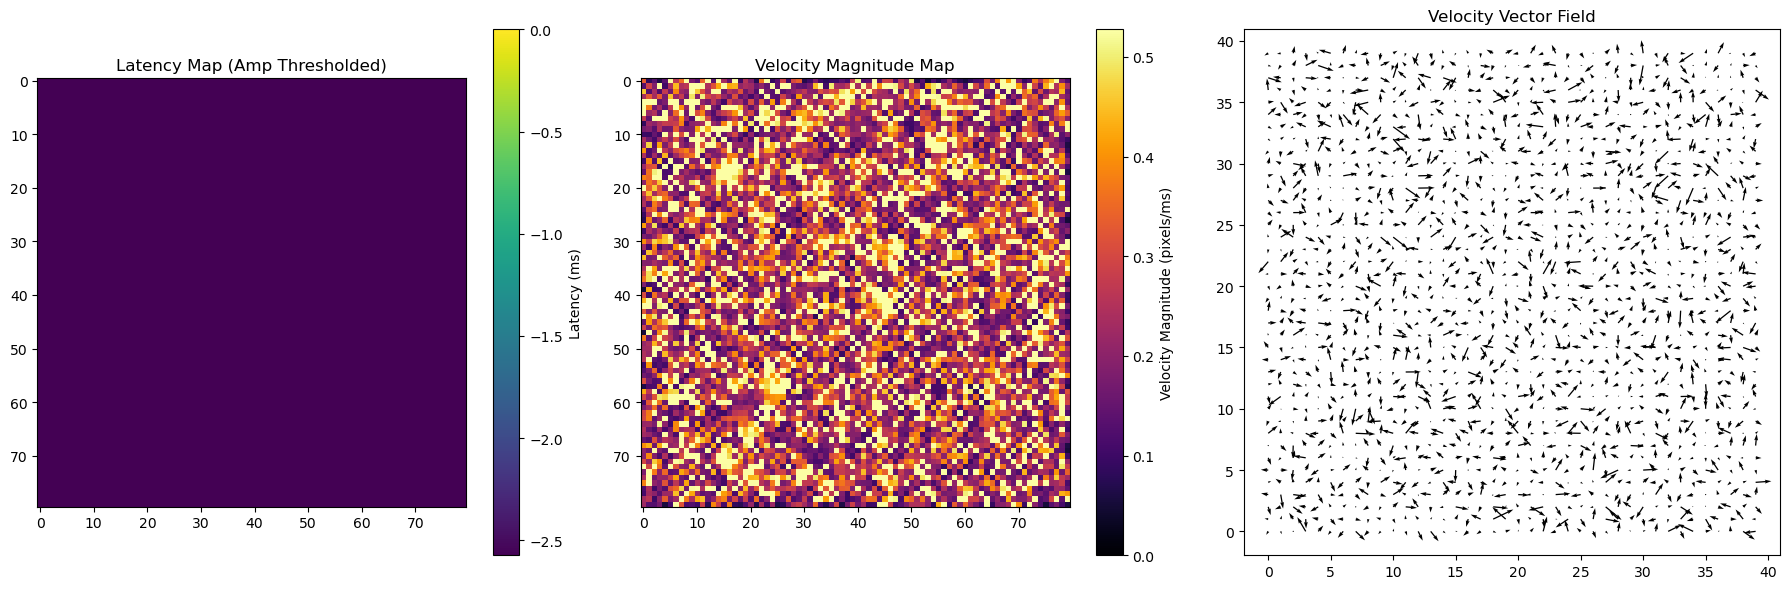

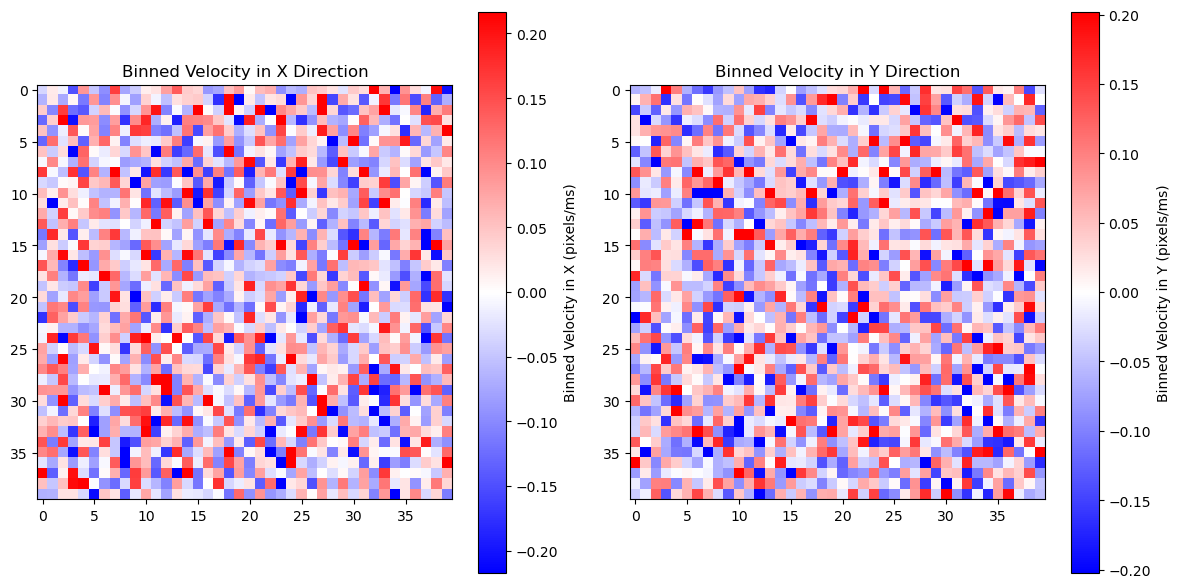

In [ ]:
# generalized velocity vector analysis
# from lat_map, thresholded at amp_map's xth percentile
xth_percentile = 0
bin_size = 1

def compute_velocity_maps(lat_map, amp_map, xth_percentile=0, bin_size=1, bin_size_velocities=2):
    # bin amp_map and lat_map
    amp_map_binned = amp_map.reshape(amp_map.shape[0]//bin_size, bin_size, amp_map.shape[1]//bin_size, bin_size).mean(axis=(1,3))
    lat_map_binned = lat_map.reshape(lat_map.shape[0]//bin_size, bin_size, lat_map.shape[1]//bin_size, bin_size).mean(axis=(1,3))
    amp_threshold = np.percentile(amp_map_binned[amp_map_binned > 0], xth_percentile)
    lat_map_masked = np.where(amp_map_binned >= amp_threshold, lat_map_binned, np.nan)

    # compute gradients
    gy, gx = np.gradient(lat_map_binned)  # gradient should be ms/pixel

    # compute velocity vectors
    magnitude = np.sqrt(gx**2 + gy**2)

    # epsilon floor: to reduce extreme velocity values due to very small gradient magnitudes (striping)
    eps = np.percentile(magnitude, 20)  # a fixed value in ms/pixel
    eps = max(eps, 0.00001)  # ensure eps is positive to avoid division by zero
    safe_mag = np.maximum(magnitude, eps)
    velocity_magnitude = 1/ safe_mag
    velocity_x = -gx / safe_mag ** 2
    velocity_y = -gy / safe_mag ** 2

    # make quiver plot from binned maps
    binned_velocity_x = velocity_x.reshape(velocity_x.shape[0]//bin_size_velocities, bin_size_velocities, 
                                           velocity_x.shape[1]//bin_size_velocities, bin_size_velocities).mean(axis=(1,3))
    binned_velocity_y = velocity_y.reshape(velocity_y.shape[0]//bin_size_velocities, bin_size_velocities, 
                                           velocity_y.shape[1]//bin_size_velocities, bin_size_velocities).mean(axis=(1,3))
    return lat_map_masked, velocity_magnitude, binned_velocity_x, binned_velocity_y

In [ ]:
# for every lat_map and amp_map in the dataset, compute and save:
#   1) the velocity vector fields, binned velocity x and y maps, and velocity magnitude map
#   2) the clustered latency and amplitude maps using the same k-means clustering approach

def sample_pairwise_neighbor_velocity_similarity(sampled_pixels, velocity_x, velocity_y, similarity_metric='dot_product'):
    similarities = []
    for px_y, px_x in sampled_pixels:
        v1 = np.array([velocity_x[px_y, px_x], velocity_y[px_y, px_x]])
        neighbor_vectors = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                n_y = px_y + dy
                n_x = px_x + dx
                if 0 <= n_y < velocity_x.shape[0] and 0 <= n_x < velocity_x.shape[1]:
                    v2 = np.array([velocity_x[n_y, n_x], velocity_y[n_y, n_x]])
                    neighbor_vectors.append(v2)
        for v2 in neighbor_vectors:
            sim = 0
            if similarity_metric == 'cosine_similarity':
                dot_product = np.dot(v1, v2)
                norm_v1 = np.linalg.norm(v1)
                norm_v2 = np.linalg.norm(v2)
                if norm_v1 == 0 or norm_v2 == 0:
                    sim = 0
                else:
                    sim = dot_product / (norm_v1 * norm_v2)
            elif similarity_metric == 'euclidean_distance':
                sim = -np.linalg.norm(v1 - v2)  # negative distance as similarity
            elif similarity_metric == 'dot_product':
                sim = np.dot(v1, v2)
            elif similarity_metric == 'angle_difference':
                # in degrees
                angle1 = np.arctan2(v1[1], v1[0]) * 180 / np.pi
                angle2 = np.arctan2(v2[1], v2[0]) * 180 / np.pi
                sim = np.abs(angle1 - angle2)
                if sim > 180:
                    sim = 360 - sim
            similarities.append(np.abs(sim))
    return similarities

0 0


In [ ]:

def convert_mask_to_rois(mask):
    # convert a 2D mask array to a list of ROIs with their x,y coordinates
    # an ROI is a block of contiguous non-zero pixels
    
    rois = []
    visited_px_map = np.zeros_like(mask, dtype=bool)
    num_nonzero_px = np.sum(mask > 0)
    num_visited_px = 0
    while num_visited_px < num_nonzero_px:
        new_roi = []
        # find first unvisited non-zero pixel
        for y in range(mask.shape[0]):
            for x in range(mask.shape[1]):
                if mask[y, x] > 0 and not visited_px_map[y, x]:
                    new_roi.append((x, y))
                    visited_px_map[y, x] = True
                    num_visited_px += 1
                    break
            if len(new_roi) > 0:
                break
        # do a flood fill to find all contiguous non-zero pixels
        roi_index = 0
        while roi_index < len(new_roi):
            px_x, px_y = new_roi[roi_index]
            # check neighbors (up, down, left, right)
            neighbors = [(px_x-1, px_y), (px_x+1, px_y), (px_x, px_y-1), (px_x, px_y+1)]
            for n_x, n_y in neighbors:
                if (0 <= n_x < mask.shape[1]) and (0 <= n_y < mask.shape[0]):
                    if mask[n_y, n_x] > 0 and not visited_px_map[n_y, n_x]:
                        new_roi.append((n_x, n_y))
                        visited_px_map[n_y, n_x] = True
                        num_visited_px += 1
            roi_index += 1

        rois.append(new_roi)

    return rois

def convert_rois_to_mask(rois, shape):
    # convert a list of ROIs with their x,y coordinates to a 2D mask array
    mask = np.zeros(shape, dtype=int)
    for roi_index, roi in enumerate(rois):
        for px_x, px_y in roi:
            mask[px_y, px_x] = roi_index + 1  # ROI indices start at 1
    return mask

def cluster_rois_by_latency_and_amplitude(output_fig_dir, date_rec_id, lat_map_masked, amp_map, lat_map,
                                          max_roi_width=6, show_plots=False, create_plots=True,
                                          verbose=True):
    # cluster ROIs by their average latency and amplitude
    # return a list of clustered ROIs, and the number of candidate ROIs:
    #   initial candidate ROIs after SNR thresholding
    #   filtered ROIs after size filtering
    #   ROIs after latency clustering and consistency filtering
    #   ROIs after amplitude clustering and consistency filtering
    #   ROIs after composite clustering and consistency filtering

    # roi must fit into a square of size max_roi_width x max_roi_width
    roi_list = convert_mask_to_rois(lat_map_masked)
    filtered_roi_list = []
    for roi in roi_list:
        xs = [px[0] for px in roi]
        ys = [px[1] for px in roi]
        if (max(xs) - min(xs) + 1) <= max_roi_width and (max(ys) - min(ys) + 1) <= max_roi_width:
            filtered_roi_list.append(roi)

    n_rois_snr_threshold = len(roi_list)
    n_rois_size_filtered = len(filtered_roi_list)
    if verbose:
        print(f"Number of initial candidate ROIs in example latency map: {len(roi_list)}")
        print(f"Number of ROIs after size filter: {len(filtered_roi_list)}")

    mask_2 = convert_rois_to_mask(filtered_roi_list, lat_map_masked.shape)
    latencies_1D = lat_map[mask_2 > 0].flatten()
    amps_1D = amp_map[mask_2 > 0].flatten()

    # cluster latencies into 6 clusters using kmeans
    kmeans_lat = KMeans(n_clusters=6, random_state=0).fit(latencies_1D.reshape(-1, 1))
    labels_lat = kmeans_lat.labels_
    # create a new latency map with clustered latencies
    lat_map_clustered = np.zeros_like(lat_map_masked)
    lat_map_clustered[mask_2 > 0] = labels_lat + 1  # cluster labels start at 0, so add 1 for visualization

    # cluster amps into 6 clusters using kmeans
    kmeans_amp = KMeans(n_clusters=6, random_state=0).fit(amps_1D.reshape(-1, 1))
    labels_amp = kmeans_amp.labels_
    # create a new amplitude map with clustered amplitudes
    amp_map_clustered = np.zeros_like(amp_map)
    amp_map_clustered[mask_2 > 0] = labels_amp + 1  # cluster labels start at 0, so add 1 for visualization

    # composite cluster label = (latency cluster) * 10 + (amplitude cluster)
    composite_map = lat_map_clustered * 10 + amp_map_clustered

    # for filtered_roi_list, look at the composite cluster labels for each ROI
    # if it's not the case that all pixels in the ROI have the same composite label, filter it out
    final_roi_list = []
    for roi in filtered_roi_list:
        roi_labels = set()
        for px_x, px_y in roi:
            roi_labels.add(composite_map[px_y, px_x])
        if len(roi_labels) == 1 and 0 not in roi_labels:
            final_roi_list.append(roi)

    n_rois_composite_clustered = len(final_roi_list)
    if verbose:
        print(f"Number of ROIs after composite cluster label consistency filter: {len(final_roi_list)}")

    final_mask = convert_rois_to_mask(final_roi_list, lat_map_masked.shape)
    final_amp_map_clustered = np.zeros_like(amp_map)
    final_amp_map_clustered[final_mask > 0] = amp_map[final_mask > 0]
    final_lat_map_clustered = np.zeros_like(lat_map_masked)
    final_lat_map_clustered[final_mask > 0] = lat_map_masked[final_mask > 0]

    # plot clustered latency and amplitude maps
    if create_plots:
        plt.figure(figsize=(12, 12))
        plt.subplot(2, 2, 1)
        plt.imshow(amp_map_clustered, cmap='tab10', vmin=0.5, vmax=6.5)
        plt.colorbar(label='Amplitude Cluster')
        plt.title('Clustered Amplitude Map')
        plt.subplot(2, 2, 2)
        plt.imshow(lat_map_clustered, cmap='tab10', vmin=0.5, vmax=6.5)
        plt.colorbar(label='Latency Cluster')
        plt.title('Clustered Latency Map')
        plt.subplot(2, 2, 3)
        plt.imshow(composite_map, cmap='tab20', vmin=0.5, vmax=66.5)
        plt.colorbar(label='Lat + Amp Cluster')
        plt.title('Composite (Lat + Amp) Clustered Map')
        plt.subplot(2, 2, 4)
        plt.imshow(final_amp_map_clustered, cmap='inferno')
        plt.colorbar(label='Amplitude (ΔF/F)')
        plt.title('Final Clustered Amplitude Map')
        plt.tight_layout()
        plt.savefig(output_fig_dir + f'clustered_latency_and_amplitude_map_{date_rec_id}.png')
        if show_plots:
            plt.show()
        plt.close()

    # alterative final list: filter by latency cluster only, not composite
    final_roi_list_2 = []
    for roi in filtered_roi_list:
        roi_labels = set()
        for px_x, px_y in roi:
            roi_labels.add(lat_map_clustered[px_y, px_x])
        if len(roi_labels) == 1 and 0 not in roi_labels:
            final_roi_list_2.append(roi)

    # alternative final list: filter by amplitude cluster only, not composite
    final_roi_list_3 = []
    for roi in filtered_roi_list:
        roi_labels = set()
        for px_x, px_y in roi:
            roi_labels.add(amp_map_clustered[px_y, px_x])
        if len(roi_labels) == 1 and 0 not in roi_labels:
            final_roi_list_3.append(roi)

    n_rois_latency_clustered = len(final_roi_list_2)
    n_rois_amplitude_clustered = len(final_roi_list_3)
    if verbose:
        print(f"Number of ROIs after latency cluster filter: {len(final_roi_list_2)}")
        print(f"Number of ROIs after amplitude cluster filter: {len(final_roi_list_3)}")

    # plot clustered latency and amplitude maps for final_roi_list_2
    final_mask_2 = convert_rois_to_mask(final_roi_list_2, lat_map_masked.shape)
    final_amp_map_clustered_2 = np.zeros_like(amp_map)
    final_amp_map_clustered_2[final_mask_2 > 0] = amp_map[final_mask_2 > 0]
    final_mask_3 = convert_rois_to_mask(final_roi_list_3, lat_map_masked.shape)
    final_amp_map_clustered_3 = np.zeros_like(amp_map)
    final_amp_map_clustered_3[final_mask_3 > 0] = amp_map[final_mask_3 > 0]

    if create_plots:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(final_amp_map_clustered_2, cmap='inferno')
        plt.colorbar(label='Amplitude (ΔF/F)')
        plt.title('Final Clustered Amplitude Map (Latency Cluster Filter)')
        plt.subplot(1, 2, 2)
        plt.imshow(final_amp_map_clustered_3, cmap='inferno')
        plt.colorbar(label='Amplitude (ΔF/F)')
        plt.title('Final Clustered Amplitude Map (Amplitude Cluster Filter)')
        plt.tight_layout()
        plt.savefig(output_fig_dir + f'final_clustered_amplitude_maps_alternatives_{date_rec_id}.png')
        if show_plots:
            plt.show()
        plt.close()

    # garbage collect
    del roi_list, filtered_roi_list, final_mask, final_mask_2, final_mask_3, composite_map
    del lat_map_clustered, amp_map_clustered, final_amp_map_clustered, final_amp_map_clustered_2, final_amp_map_clustered_3
    gc.collect()

    roi_clusters = {
        'latency_clustered': final_roi_list_2,
        'amplitude_clustered': final_roi_list_3,
        'composite_clustered': final_roi_list
    }
    n_rois_dict = {
        'n_rois_snr_threshold': n_rois_snr_threshold,
        'n_rois_size_filtered': n_rois_size_filtered,
        'n_rois_latency_clustered': n_rois_latency_clustered,
        'n_rois_amplitude_clustered': n_rois_amplitude_clustered,
        'n_rois_composite_clustered': n_rois_composite_clustered
    }
    return roi_clusters, n_rois_dict


In [ ]:
def highlight_cell(x,y, ax=None, **kwargs):
    rect = plt.Rectangle((x-.5, y-.5), 1,1, fill=False, **kwargs)
    ax = ax or plt.gca()
    ax.add_patch(rect)
    return rect

def outline_region(pixels_or_mask, ax=None, shape=None, extent=None, origin='lower',
                   color=(1,0,0,0.5), linewidth=3):
    """
    Outline a set of pixels on an existing Matplotlib axes.

    Parameters
    - pixels_or_mask: iterable of (row, col) pairs OR a 2D boolean/0-1 array (mask).
                      Row = y, Col = x (0-based).
    - ax: matplotlib Axes to draw on (defaults to plt.gca()).
    - shape: (nrows, ncols) to define grid size if passing pixel list (optional).
             If None, inferred from pixel coordinates.
    - extent: (x0, y0, x1, y1) maps pixel-grid coords to axis coords (optional).
              If None, coordinates are left in pixel units.
    - origin: 'lower' (default) or 'upper' — matches imshow origin behavior.
    - color, linewidth: plotting style.

    Returns: the Axes instance used (or None if nothing drawn)
    """
    if ax is None:
        ax = plt.gca()

    # Accept mask array directly
    if isinstance(pixels_or_mask, (np.ndarray, list)) and getattr(pixels_or_mask, 'ndim', None) == 2:
        mapimg = np.asarray(pixels_or_mask).astype(bool)
    else:
        pixels = np.asarray(list(pixels_or_mask), dtype=int)
        if pixels.size == 0:
            return ax
        if shape is None:
            nrows = pixels[:,0].max() + 1
            ncols = pixels[:,1].max() + 1
            shape = (nrows, ncols)
        mapimg = np.zeros(shape, dtype=bool)
        rr, cc = pixels[:,0], pixels[:,1]
        valid = (rr >= 0) & (rr < shape[0]) & (cc >= 0) & (cc < shape[1])
        mapimg[rr[valid], cc[valid]] = True

    # detect boundary segments (following your original approach)
    ver_seg = np.where(mapimg[:,1:] != mapimg[:,:-1])
    hor_seg = np.where(mapimg[1:,:] != mapimg[:-1,:])

    pts = []
    for p in zip(*hor_seg):
        pts.append((p[1], p[0]+1))
        pts.append((p[1]+1, p[0]+1))
        pts.append((np.nan, np.nan))
    for p in zip(*ver_seg):
        pts.append((p[1]+1, p[0]))
        pts.append((p[1]+1, p[0]+1))
        pts.append((np.nan, np.nan))

    if not pts:
        return ax

    segments = np.array(pts, dtype=float)

    # handle origin flip to match imshow(origin='upper')
    if origin == 'upper':
        segments[:,1] = mapimg.shape[0] - segments[:,1]

    # apply extent mapping if provided: (x0, y0, x1, y1)
    if extent is not None:
        x0, y0, x1, y1 = extent
        segments[:,0] = x0 + (x1 - x0) * segments[:,0] / mapimg.shape[1]
        segments[:,1] = y0 + (y1 - y0) * segments[:,1] / mapimg.shape[0]

    ax.plot( segments[:,1], segments[:,0], color=color, linewidth=linewidth)
    return ax

def find_contiguous_subregion_of_cosine_similarity(angle_similarity_map, angle_threshold=30):
    ''' if the angle difference between velocity vectors is less than angle_threshold (in degrees),
    group them into contiguous subregions using flood fill algorithm'''
    visited = np.zeros_like(angle_similarity_map, dtype=bool)
    subregions = []
    for y in range(angle_similarity_map.shape[0]):
        for x in range(angle_similarity_map.shape[1]):
            if visited[y, x]:
                continue
            angle = angle_similarity_map[y, x]
            if np.isnan(angle):
                continue
            new_region = []
            queue = [(x, y)]
            while queue:
                px_x, px_y = queue.pop(0)
                if visited[px_y, px_x]:
                    continue
                visited[px_y, px_x] = True
                new_region.append((px_x, px_y))
                # check neighbors
                for dy in [-1, 0, 1]:
                    for dx in [-1, 0, 1]:
                        if dy == 0 and dx == 0:
                            continue
                        n_x = px_x + dx
                        n_y = px_y + dy
                        if 0 <= n_x < angle_similarity_map.shape[1] and 0 <= n_y < angle_similarity_map.shape[0]:
                            neighbor_angle = angle_similarity_map[n_y, n_x]
                            if not visited[n_y, n_x] and not np.isnan(neighbor_angle):
                                angle_diff = np.abs(angle - neighbor_angle) 
                                if angle_diff > 180:
                                    angle_diff = 360 - angle_diff
                                if angle_diff <= angle_threshold:
                                    queue.append((n_x, n_y))
            if len(new_region) > 0:
                subregions.append(new_region)
    return subregions

def compute_low_latency_and_vector_sim_subregions(output_file_png, amp_map, lat_map_masked, velocity_x, velocity_y, 
                                                  amp_threshold_percentile=50, similarity_metric='dot_product', 
                                                  show_plots=False, close_plots=False):
    # find pixels in the masked lat_map where the latency is less than at least 5 of its 8 neighbors
    amp_threshold = np.percentile(amp_map[amp_map > 0], amp_threshold_percentile)
    low_latency_pixels = []
    for y in range(1, lat_map_masked.shape[0]-1):
        for x in range(1, lat_map_masked.shape[1]-1):
            center_latency = lat_map_masked[y, x]
            if np.isnan(center_latency) or center_latency <= 0.2:
                continue
            neighbor_latencies = [
                lat_map_masked[y-1, x-1], lat_map_masked[y-1, x], lat_map_masked[y-1, x+1],
                lat_map_masked[y, x-1],                     lat_map_masked[y, x+1],
                lat_map_masked[y+1, x-1], lat_map_masked[y+1, x], lat_map_masked[y+1, x+1]
            ]
            # allow at most 3 neighbors to be nan
            nan_count = sum(1 for nl in neighbor_latencies if np.isnan(nl))
            if nan_count > 3:
                continue
            if center_latency < min(nl for nl in neighbor_latencies):
                low_latency_pixels.append((x, y))

    low_latency_neighbor_similarities = []
    low_latency_neighbor_similarities.extend(
                        sample_pairwise_neighbor_velocity_similarity(low_latency_pixels, velocity_x, velocity_y, similarity_metric)
                    )
    control_random_pixels = []
    attempts = 10000
    while len(control_random_pixels) < len(low_latency_pixels) and attempts > 0:
        attempts -= 1
        rand_x = np.random.randint(1, lat_map_masked.shape[1]-1)
        rand_y = np.random.randint(1, lat_map_masked.shape[0]-1)
        if np.isnan(lat_map_masked[rand_y, rand_x]):
            continue
        if (rand_x, rand_y) not in control_random_pixels:
            control_random_pixels.append((rand_x, rand_y))
            break
    random_neighbor_similarities = []
    random_neighbor_similarities.extend(
                        sample_pairwise_neighbor_velocity_similarity(control_random_pixels, velocity_x, velocity_y, similarity_metric)
                    )

    # compare latencies of low_latency_pixels to their neighbors
    latencies_low = [lat_map_masked[y, x] for x, y in low_latency_pixels]
    latencies_neighbor = []
    for x, y in low_latency_pixels:
        neighbor_latencies = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                n_y = y + dy
                n_x = x + dx
                neighbor_latency = lat_map_masked[n_y, n_x]
                if not np.isnan(neighbor_latency):
                    neighbor_latencies.append(neighbor_latency)
        latencies_neighbor.append(np.mean(neighbor_latencies))

    # build vector angle map
    velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
    angle_map = np.zeros_like(velocity_x)  # angle map will be the angle of the velocity vector at each pixel
    angle_map[:] = np.nan
    for y in range(velocity_x.shape[0]):
        for x in range(velocity_x.shape[1]):
            if not np.isnan(velocity_x[y, x]) and not np.isnan(velocity_y[y, x]) \
                and amp_map[y, x] > amp_threshold \
                    and velocity_magnitude[y, x] < 10000 \
                        and velocity_magnitude[y, x] > 0.1:
                angle_map[y, x] = np.arctan2(velocity_y[y, x], velocity_x[y, x]) * 180 / np.pi  # in degrees

    subregions = find_contiguous_subregion_of_cosine_similarity(angle_map, angle_threshold=30)  # degrees
    # keep only subregions larger than x pixels
    min_subregion_size = 4
    subregions = [sr for sr in subregions if len(sr) >= min_subregion_size]

    # show lat_map_masked
    plt.figure(figsize=(27, 27))
    plt.subplot(3, 3, 1)
    plt.imshow(lat_map_masked, cmap='viridis', vmin=0)
    plt.colorbar(label='Latency (ms)')
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='white', linewidth=0.5)
    plt.title('Latency Map (Amp Thresholded)')
    plt.subplot(3, 3, 2)
    plt.imshow(amp_map, cmap='inferno')
    plt.colorbar(label='Amplitude (ΔF/F)')
    plt.title('Amplitude Map')
    plt.tight_layout()
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='white', linewidth=0.5)
    plt.subplot(3, 3, 3)
    velocity_magnitude[velocity_magnitude > 10000] = 0
    plt.imshow(velocity_magnitude, cmap='inferno', vmin=0.5, vmax=np.percentile(velocity_magnitude, 95))
    plt.colorbar(label='Velocity Magnitude (pixels/ms)')
    plt.title('Velocity Magnitude Map')
    plt.tight_layout()
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='black', linewidth=0.5)
    plt.subplot(3, 3, 4)
    plt.imshow(velocity_x, cmap='bwr', vmin=-np.percentile(np.abs(velocity_x), 95), vmax=np.percentile(np.abs(velocity_x), 95))
    plt.title('Velocity in X Direction')
    plt.colorbar(label='Velocity X (pixels/ms)')
    plt.tight_layout()
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='black', linewidth=1)
    plt.subplot(3, 3, 5)
    plt.imshow(velocity_y, cmap='bwr', vmin=-np.percentile(np.abs(velocity_y), 95), vmax=np.percentile(np.abs(velocity_y), 95))
    plt.title('Velocity in Y Direction')
    plt.colorbar(label='Velocity Y (pixels/ms)')
    plt.tight_layout()
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='black', linewidth=1)

    plt.subplot(3, 3, 6)
    # barplot and scatter of latencies_low vs latencies_neighbor's latencies
    labels = ['Low Latency Pixels', 'Neighboring Pixels']
    x = np.arange(len(labels))
    means = [np.mean(latencies_low), np.mean(latencies_neighbor)]
    sems = [np.std(latencies_low)/np.sqrt(len(latencies_low)), np.std(latencies_neighbor)/np.sqrt(len(latencies_neighbor))]
    plt.bar(x, means, yerr=sems, capsize=5, color=['blue', 'orange'], alpha=0.6, width=0.5, edgecolor='black')
    x_jitter = np.random.normal(0, 0.05, size=len(latencies_low))
    plt.scatter(np.zeros(len(latencies_low)) + 0.1 * (np.random.rand(len(latencies_low)) - 0.5) + x_jitter, latencies_low, color='blue', alpha=0.6)
    x_jitter = np.random.normal(0, 0.05, size=len(latencies_neighbor))
    plt.scatter(np.ones(len(latencies_neighbor)) + 0.1 * (np.random.rand(len(latencies_neighbor)) - 0.5) + x_jitter, latencies_neighbor, color='orange', alpha=0.6)
    plt.xticks(x, labels)
    plt.ylabel('Latency (ms)')

    plt.subplot(3, 3, 7)
    plt.imshow(angle_map, cmap='hsv')
    plt.colorbar(label='Angle (radians)')
    plt.title('Angle Map')
    for subregion in subregions:
        outline_region(subregion, ax=plt.gca(), color='black', linewidth=2)

    plt.subplot(3, 3, 8)
    blank = np.zeros_like(angle_map)
    blank[:] = np.nan
    # shade each subregion
    for i, subregion in enumerate(subregions):
        id = np.random.randint(0, len(subregions))
        for x, y in subregion:
            blank[y, x] = angle_map[y, x]
    for x, y in low_latency_pixels:
        highlight_cell(x, y, color='black', linewidth=1)
    plt.imshow(blank, cmap='hsv')
    plt.colorbar(label='Velocity Angle')
    plt.title('Subregions of Similar Velocity Angles')
    plt.savefig(output_file_png)
    if show_plots:
        plt.show()
    if close_plots:
        plt.close()

    # garbage collection to free memory
    del lat_map_masked, velocity_x, velocity_y, angle_map, velocity_magnitude, blank, latencies_low, latencies_neighbor
    gc.collect()

    return low_latency_pixels, subregions

def run_all_clustering_methods(lat_map, amp_map, amp_percentile_threshold=50, max_roi_width=6, output_keyword="", show_plots=True):
    # generalized velocity vector analysis
        # from lat_map, thresholded at amp_map's xth percentile
    lat_map_masked, velocity_magnitude, velocity_x, velocity_y = \
        compute_velocity_maps(lat_map, amp_map, xth_percentile=amp_percentile_threshold, bin_size=1, bin_size_velocities=1)
    low_latency_pixels, subregions = compute_low_latency_and_vector_sim_subregions(
        output_fig_dir + f'low_latency_and_vector_similarity_subregions_{output_keyword}.png',
        amp_map,
        lat_map_masked, velocity_x, velocity_y, amp_threshold_percentile=amp_percentile_threshold, 
        similarity_metric='angle_difference', show_plots=show_plots, close_plots=True
    )

    roi_clusters, n_rois_dict = cluster_rois_by_latency_and_amplitude(output_fig_dir, output_keyword, lat_map_masked, 
                                                                      amp_map, lat_map, max_roi_width=max_roi_width, show_plots=show_plots,
                                                                      verbose=False, create_plots=False)
    
    return roi_clusters, n_rois_dict, low_latency_pixels, subregions, velocity_x, velocity_y

def do_rois_overlap(roi1, roi2):
    # Check if two ROIs overlap
    for px1 in roi1:
        for px2 in roi2:
            if px1[0] == px2[0] and px1[1] == px2[1]:
                return True
    return False

def count_overlap_all_ways(subregions, low_latency_pixels, composite_clustered_rois):

    overlap_counts = {
        'subregions_vs_low_latency': 0,
        'subregions_vs_composite_clustered': 0,
        'low_latency_vs_composite_clustered': 0,
        'all_ways': 0
    }
    for roi in composite_clustered_rois:
        # check overlap with low_latency_pixels
        for px in low_latency_pixels:
            ll_roi = [px]
            if do_rois_overlap(roi, ll_roi):
                overlap_counts['low_latency_vs_composite_clustered'] += 1
    for subregion in subregions:
        # check overlap with low_latency_pixels
        for px in low_latency_pixels:
            ll_roi = [px]
            if do_rois_overlap(subregion, ll_roi):
                overlap_counts['subregions_vs_low_latency'] += 1

        # check overlap with composite_clustered_rois
        for roi in composite_clustered_rois:
            if do_rois_overlap(subregion, roi):
                overlap_counts['subregions_vs_composite_clustered'] += 1
            for px in low_latency_pixels:
                ll_roi = [px]
                if do_rois_overlap(subregion, ll_roi):
                    overlap_counts['all_ways'] += 1

    return overlap_counts

In [30]:
n_to_show = 0
n_roi_stats = {}
subregion_velocities = {}
# load all the keys to skip from the csv if it exists
if os.path.exists(output_fig_dir + 'n_roi_stats_summary.csv'):
    existing_df = pd.read_csv(output_fig_dir + 'n_roi_stats_summary.csv', index_col=0)
    n_roi_keys_to_skip = existing_df.index.tolist()
else:
    n_roi_keys_to_skip = []

# load subregion velocities if they exist
if os.path.exists(output_fig_dir + 'subregion_velocities.csv'):
    subregion_velocities_df = pd.read_csv(output_fig_dir + 'subregion_velocities.csv', index_col=0)
    for idx, row in subregion_velocities_df.iterrows():
        subregion_velocities[idx] = (row['x_velocity'], row['y_velocity'], row['x_velocity_std'],
                                     row['y_velocity_std'], row['subregion_size'], row['subregion_file'])

for date in ppr_df['Date'].unique():
    date_df = ppr_df[ppr_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            for recording in location_df['Recording'].unique():
                recording_df = location_df[location_df['Recording'] == recording]

                n_roi_stats_key = f'{date}_{slic}_{location}_{recording}'
                if n_roi_stats_key in n_roi_keys_to_skip:
                    continue

                # find the corresponding lat_map and amp_map files
                lat_map_file = recording_df.iloc[0]['latency_array']
                amp_map_file = recording_df.iloc[0]['amp_array']
                stim_time = recording_df.iloc[0]['stim_time']
                lat_map = read_array_file(lat_map_file) - stim_time
                amp_map = read_array_file(amp_map_file)

                roi_clusters, n_rois_dict, low_latency_pixels, subregions, velocity_x, velocity_y = run_all_clustering_methods(
                    lat_map, amp_map, amp_percentile_threshold=80, max_roi_width=3,
                    output_keyword=f'{date.replace("/", "")}_{slic}_{location}_{recording}', show_plots=(n_to_show > 0))
                n_to_show -= 1
                subreg_output_file = 'C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/' + f'subregions_{n_roi_stats_key}.dat'

                for i, subregion in enumerate(subregions):
                    subregion_velocity_x = np.mean([velocity_x[px[1], px[0]] for px in subregion])
                    subregion_velocity_y = np.mean([velocity_y[px[1], px[0]] for px in subregion])

                    # convert ms/pixel to um/ms (conversion um_per_px per pixel)
                    subregion_velocity_x = um_per_px / subregion_velocity_x if subregion_velocity_x != 0 else 0
                    subregion_velocity_y = um_per_px / subregion_velocity_y if subregion_velocity_y != 0 else 0

                    # std dev of velocity vectors within subregion
                    subregion_velocity_x_std = np.std([velocity_x[px[1], px[0]] for px in subregion])
                    subregion_velocity_y_std = np.std([velocity_y[px[1], px[0]] for px in subregion])
                    # convert ms/pixel to um/ms
                    subregion_velocity_x_std = um_per_px / subregion_velocity_x_std if subregion_velocity_x_std != 0 else 0
                    subregion_velocity_y_std = um_per_px / subregion_velocity_y_std if subregion_velocity_y_std != 0 else 0

                    # number of pixels in subregion
                    subregion_size = len(subregion)

                    # turn subregion into mask and 

                    subregion_velocities[f'{n_roi_stats_key}_subregion_{i}'] = (subregion_velocity_x, subregion_velocity_y, subregion_velocity_x_std, subregion_velocity_y_std, subregion_size, subreg_output_file)

                # count number of low_latency_pixels and subregions
                n_low_latency_pixels = len(low_latency_pixels)
                n_subregions = len(subregions)
                n_subregions_px_count = sum(len(sr) for sr in subregions)

                # keep n_roi stats
                n_roi_stats[n_roi_stats_key] = {
                    'n_low_latency_pixels': n_low_latency_pixels,
                    'n_subregions': n_subregions,
                    'n_subregions_px_count': n_subregions_px_count
                }
                for k, v in n_rois_dict.items():
                    n_roi_stats[n_roi_stats_key][k] = v

                # count overlaps
                overlap_counts = count_overlap_all_ways(subregions, low_latency_pixels, roi_clusters)
                n_roi_stats[n_roi_stats_key].update(overlap_counts)
                # save subregions to file for later velocity analysis
                
                roi_writer = ROIFileWriter()
                # rewrite to file
                roi_writer.write_regions_to_dat(subreg_output_file, subregions, input_format_diode_nums=False)

                # garbage collect
                del lat_map, amp_map, subregions, low_latency_pixels, roi_clusters
                gc.collect()

                # add n_roi_stats_key to n_roi_keys_to_skip to avoid re-processing
                n_roi_keys_to_skip.append(n_roi_stats_key)

        # save slice stats to file
        n_roi_stats_df = pd.DataFrame.from_dict(n_roi_stats, orient='index')
        if not os.path.exists(output_fig_dir + 'n_roi_stats_summary.csv'):
            n_roi_stats_df.to_csv(output_fig_dir + 'n_roi_stats_summary.csv')
        else: 
            # append to existing csv
            existing_df = pd.read_csv(output_fig_dir + 'n_roi_stats_summary.csv', index_col=0)
            combined_df = pd.concat([existing_df, n_roi_stats_df])
            # remove duplicates
            combined_df = combined_df[~combined_df.index.duplicated(keep='last')]
            # overwrite csv
            combined_df.to_csv(output_fig_dir + 'n_roi_stats_summary.csv')
        
        # save subregion velocities to file
        sub_v_columns = list(subregion_velocities.keys())
        sub_v_x = [v[0] for v in subregion_velocities.values()]
        sub_v_y = [v[1] for v in subregion_velocities.values()]
        sub_v_x_std = [v[2] for v in subregion_velocities.values()]
        sub_v_y_std = [v[3] for v in subregion_velocities.values()]
        subregion_velocities_df = pd.DataFrame({
            'x_velocity': sub_v_x, 
            'y_velocity': sub_v_y,
            'x_velocity_std': sub_v_x_std,
            'y_velocity_std': sub_v_y_std,
            'subregion_size': [v[4] for v in subregion_velocities.values()],
            'subregion_file': [v[5] for v in subregion_velocities.values()]
        }, index=sub_v_columns)
        if not os.path.exists(output_fig_dir + 'subregion_velocities.csv'):
            subregion_velocities_df.to_csv(output_fig_dir + 'subregion_velocities.csv')
        else:
            existing_df = pd.read_csv(output_fig_dir + 'subregion_velocities.csv', index_col=0)
            combined_df = pd.concat([existing_df, subregion_velocities_df])
            combined_df = combined_df[~combined_df.index.duplicated(keep='last')]
            combined_df.to_csv(output_fig_dir + 'subregion_velocities.csv')
        # print current n_roi_keys_to_skip
        print(f'Processed date {date} slice {slic}, updated n_roi_keys_to_skip length: {len(n_roi_keys_to_skip)}')

        # garbage collect at end of slice
        gc.collect()



Processed date 22-9-2 slice 2, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-2 slice 3, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-2 slice 4, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-2 slice 5, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-2 slice 6, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-2 slice 7, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 1, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 2, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 3, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 4, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 5, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 6, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-15 slice 7, updated n_roi_keys_to_skip length: 1173
Processed date 22-9-16 slice 1, updated n_roi_keys_to_skip length: 117

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scala

Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_1_3.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_1_3.dat


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scala

Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_1_4.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_1_4.dat
Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_2_1.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-13_1_2_1.dat


...

Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_2.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_2.dat


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scala

Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_3.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_3.dat


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scala

Overwriting C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_4.dat
Regions written to: C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/subregions/subregions_23-9-17_7_3_4.dat
Processed date 23-9-17 slice 7, updated n_roi_keys_to_skip length: 1446


In [31]:


# save n_roi_stats to csv
n_roi_stats_df = pd.DataFrame.from_dict(n_roi_stats, orient='index')
if not os.path.exists(output_fig_dir + 'n_roi_stats_summary.csv'):
    n_roi_stats_df.to_csv(output_fig_dir + 'n_roi_stats_summary.csv')
else: 
    # append to existing csv
    existing_df = pd.read_csv(output_fig_dir + 'n_roi_stats_summary.csv', index_col=0)
    combined_df = pd.concat([existing_df, n_roi_stats_df])
    # remove duplicates
    combined_df = combined_df[~combined_df.index.duplicated(keep='last')]
    # overwrite csv
    combined_df.to_csv(output_fig_dir + 'n_roi_stats_summary.csv')

Index(['n_low_latency_pixels', 'n_subregions', 'n_subregions_px_count',
       'n_rois_snr_threshold', 'n_rois_size_filtered',
       'n_rois_latency_clustered', 'n_rois_amplitude_clustered',
       'n_rois_composite_clustered', 'subregions_vs_low_latency',
       'subregions_vs_composite_clustered',
       'low_latency_vs_composite_clustered', 'all_ways'],
      dtype='object')


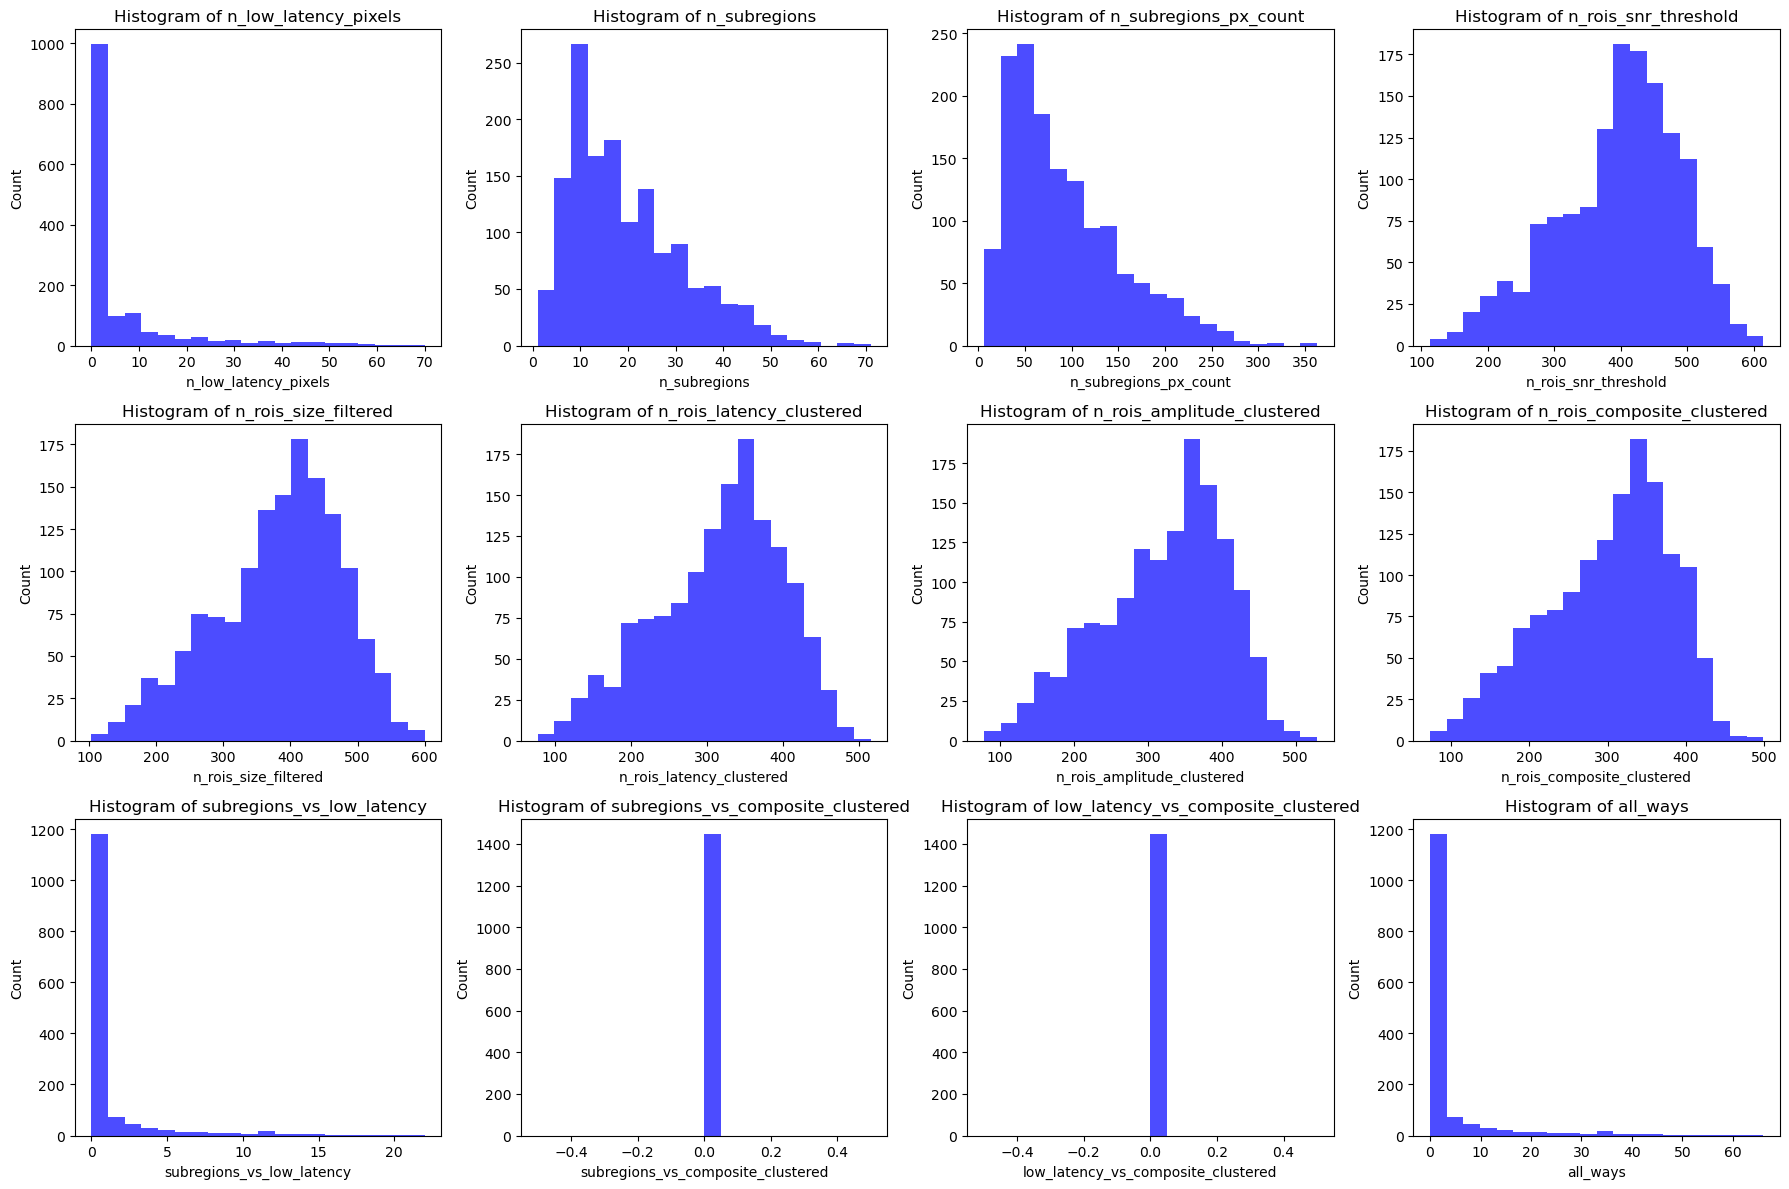

fraction of low latency pixels that overlap with subregions: 0.16518400530233143
fraction of SNR thresholded area that is covered by subregions: 0.07227535010373445


In [32]:
# read n_roi_stats from csv
n_roi_stats_df = pd.read_csv(output_fig_dir + 'n_roi_stats_summary.csv', index_col=0)
print(n_roi_stats_df.columns)
# show summary histograms of n_roi_stats_df columns
plt.figure(figsize=(18, 12))
for i, column in enumerate(n_roi_stats_df.columns):
    plt.subplot(3, 4, i+1)
    plt.hist(n_roi_stats_df[column], bins=20, color='blue', alpha=0.7)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
plt.tight_layout()
plt.savefig(output_fig_dir + 'n_roi_stats_histograms.png')
plt.show()
plt.close()

# read subregion velocities from csv
subregion_velocities_df = pd.read_csv(output_fig_dir + 'subregion_velocities.csv', index_col=0)

print("fraction of low latency pixels that overlap with subregions:",
      np.mean(n_roi_stats_df['subregions_vs_low_latency'] / n_roi_stats_df['n_low_latency_pixels']))
print("fraction of SNR thresholded area that is covered by subregions:",
      np.mean(n_roi_stats_df['n_subregions_px_count'] / (0.2 * 6400))) # assuming 80x80 map with 20% area above SNR threshold

In [33]:
# group subregion velocities by what layer was stimulated (look up layer in ppr_df)
subregion_velocities_df["Layer"] = ""
for idx, row in subregion_velocities_df.iterrows():
    # idx format: '2023-09-11_07_01_01_L4_subregion_0'
    parts = idx.split('_')
    date = parts[0]
    slic = int(parts[1])
    location = int(parts[2])
    recording = int(parts[3])
    

    layer = ppr_df[(ppr_df['Date'] == date) & 
                   (ppr_df['Slice'] == slic) & 
                   (ppr_df['Location'] == location) & 
                   (ppr_df['Recording'] == recording)]
    layer = layer.iloc[0]['Stim_Layer']
    
    subregion_velocities_df.at[idx, 'Layer'] = layer
subregion_velocities_df.to_csv(output_fig_dir + 'subregion_velocities_with_stim_layer.csv')

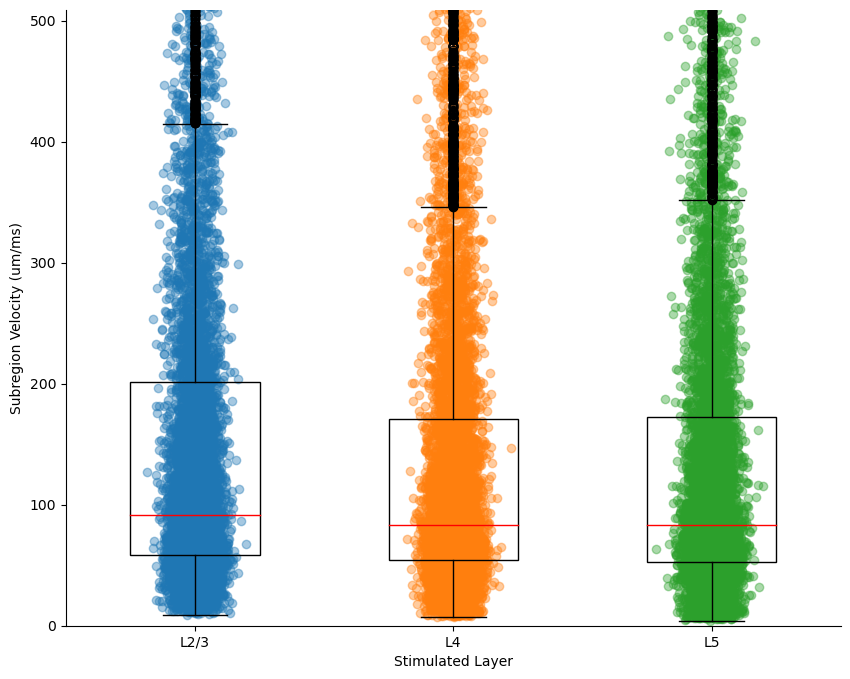

In [34]:
# plot velocity scatter plot in groups by stimulated layer
plt.figure(figsize=(10, 8))
layers = subregion_velocities_df['Layer'].unique()
colors = {"L2/3": 'tab:blue', "L4": 'tab:orange', "L5": 'tab:green'}
for i, layer in enumerate(layers):
    layer_df = subregion_velocities_df[subregion_velocities_df['Layer'] == layer]
    velocity = np.sqrt(layer_df['x_velocity']**2 + layer_df['y_velocity']**2)
    x_jitter = np.random.normal(0, 0.05, size=len(layer_df)) + i  # add i to separate groups on x-axis
    plt.scatter(x_jitter, velocity, color=colors[layer], label=layer, alpha=0.4)
plt.ylabel('Subregion Velocity (um/ms)')

plt.xlabel('Stimulated Layer')
plt.ylim(0, np.percentile(subregion_velocities_df.apply(lambda row: np.sqrt(row['x_velocity']**2 + row['y_velocity']**2), axis=1), 95) // 2)

# boxplots over the scatter
box_data = [subregion_velocities_df[subregion_velocities_df['Layer'] == layer].apply(lambda row: np.sqrt(row['x_velocity']**2 + row['y_velocity']**2), axis=1) for layer in layers]
plt.boxplot(box_data, positions=range(len(layers)), widths=0.5, patch_artist=True, boxprops=dict(facecolor='none', color='black'), medianprops=dict(color='red'))
plt.xticks(range(len(layers)))
plt.gca().set_xticklabels(['L2/3', 'L4', 'L5'])

# spines off
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig(output_fig_dir + 'subregion_velocities_by_layer.png')
plt.show()


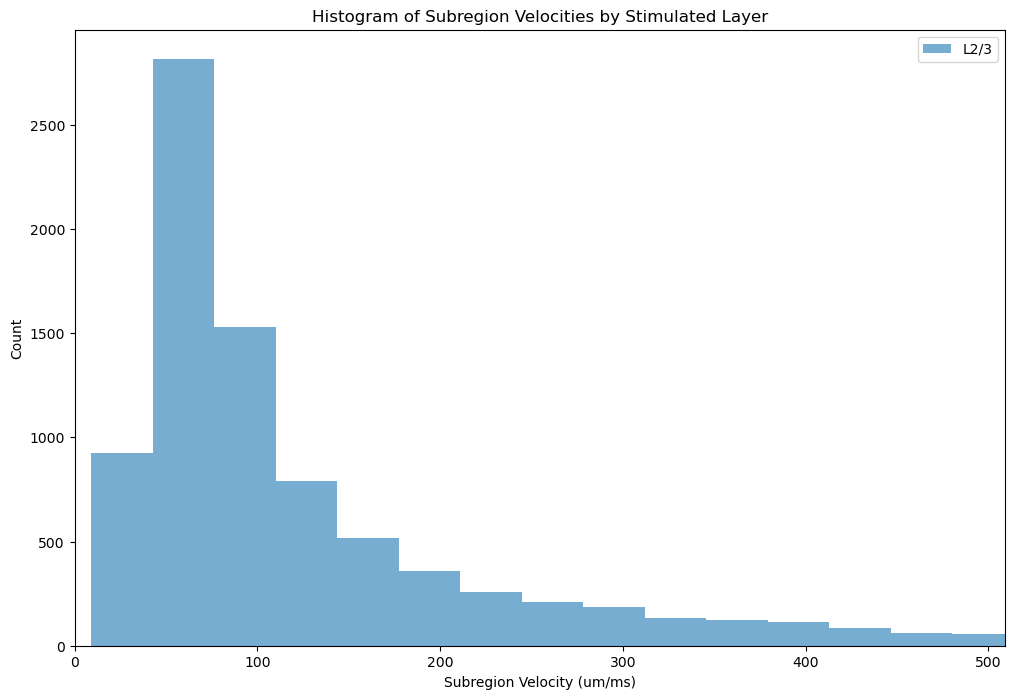

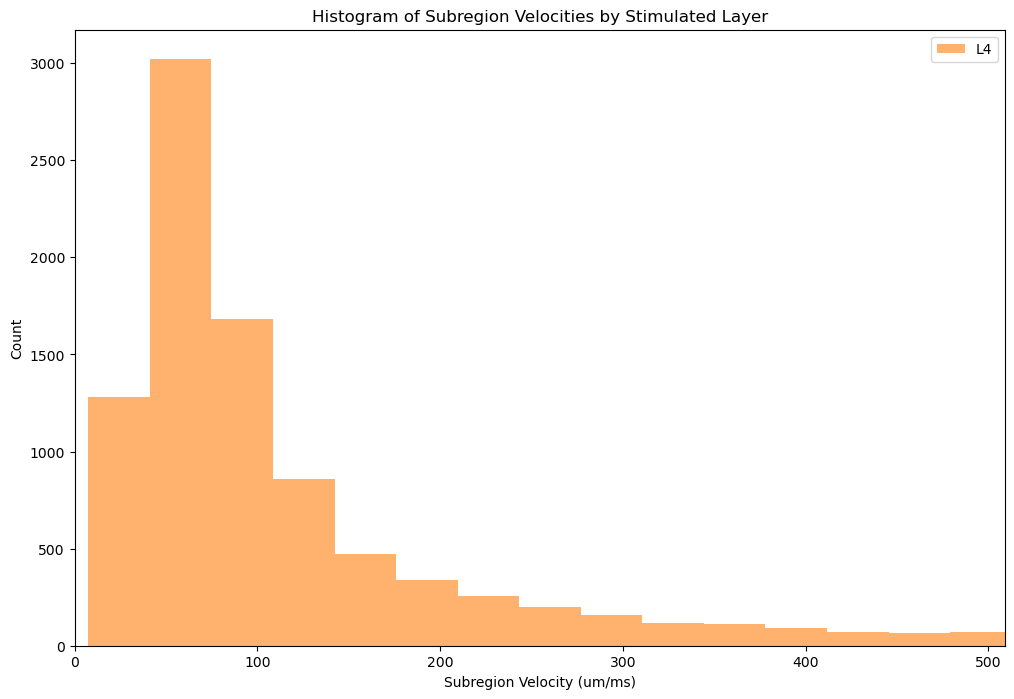

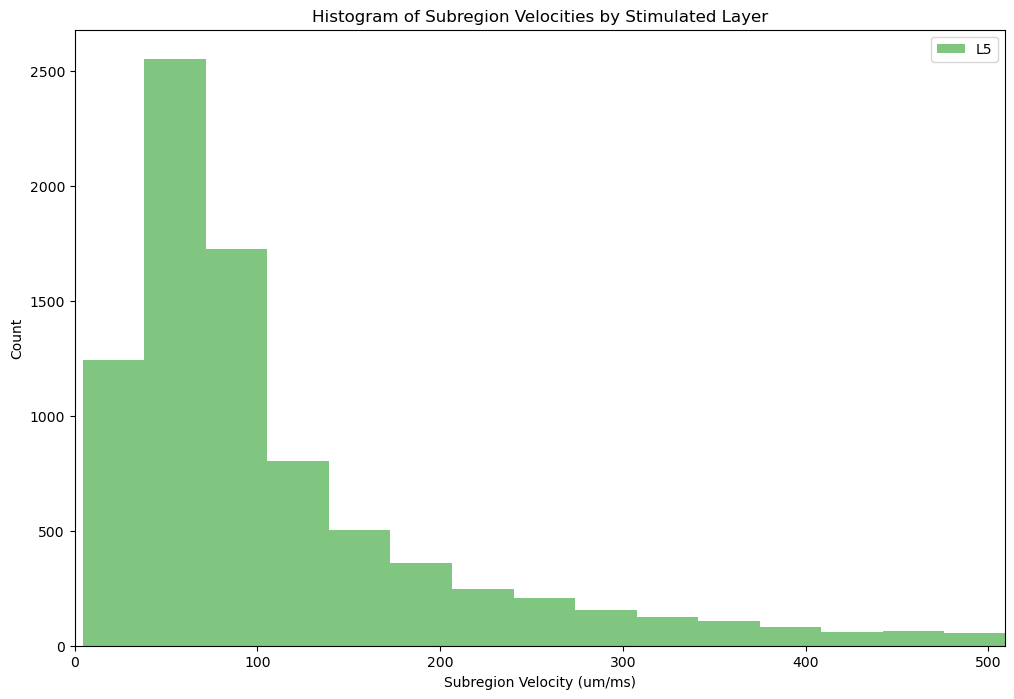

In [35]:
# histogram of subregion velocities by layer
for i, layer in enumerate(layers):
    layer_df = subregion_velocities_df[subregion_velocities_df['Layer'] == layer]
    velocity = np.sqrt(layer_df['x_velocity']**2 + layer_df['y_velocity']**2)
    # cut off x axis at 95th percentile of all subregion velocities to zoom in on bulk of distribution
    velocity = velocity[velocity < np.percentile(subregion_velocities_df.apply(lambda row: np.sqrt(row['x_velocity']**2 + row['y_velocity']**2), axis=1), 95)]
    plt.figure(figsize=(12, 8))
    plt.hist(velocity, bins=30, color=colors[layer], label=layer, alpha=0.6)
    plt.xlabel('Subregion Velocity (um/ms)')
    plt.ylabel('Count')
    plt.title('Histogram of Subregion Velocities by Stimulated Layer')
    plt.legend()
    plt.xlim(0, np.percentile(subregion_velocities_df.apply(lambda row: np.sqrt(row['x_velocity']**2 + row['y_velocity']**2), axis=1), 95) // 2)
    plt.savefig(output_fig_dir + f'subregion_velocity_histograms_layer{layer.replace("/", "")}.png')
    plt.show()

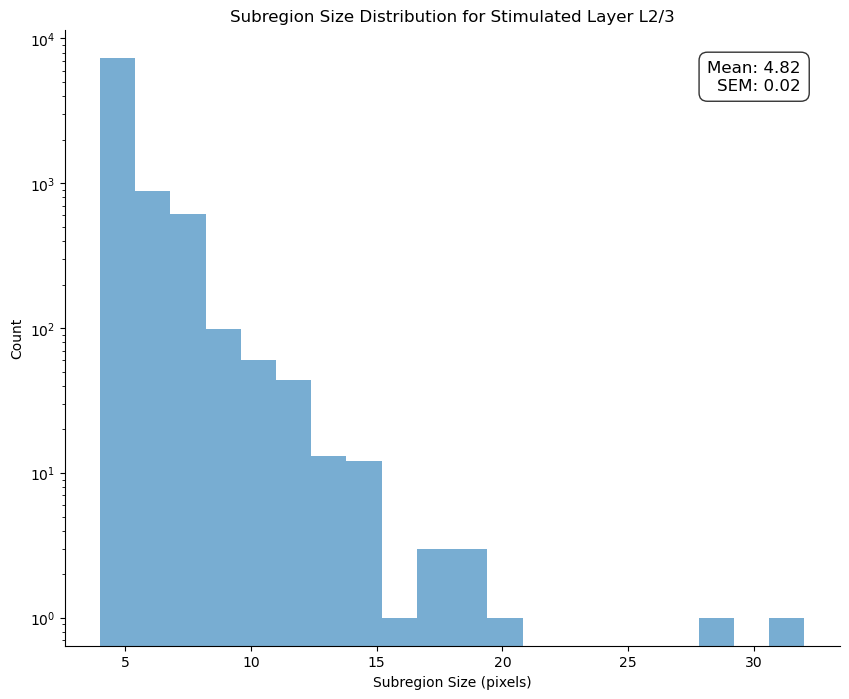

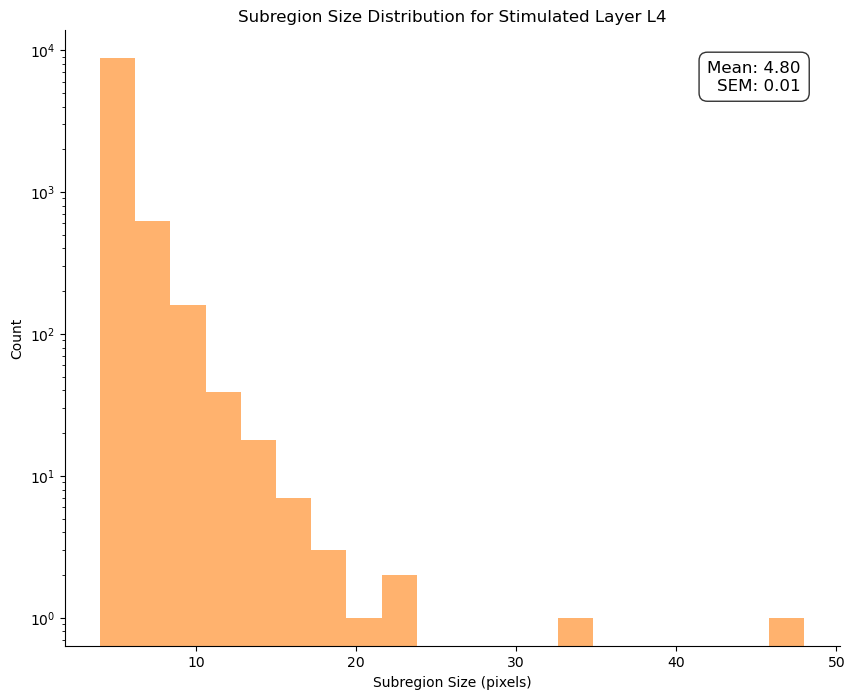

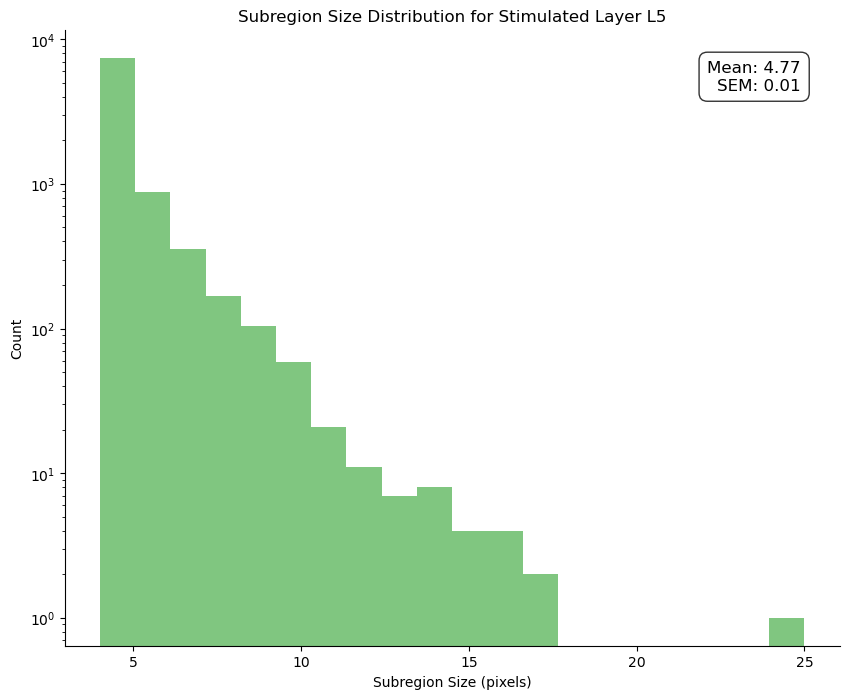

In [36]:
# show subregion size histograms by layer
for i, layer in enumerate(layers):
    plt.figure(figsize=(10, 8))

    layer_df = subregion_velocities_df[subregion_velocities_df['Layer'] == layer]
    size = layer_df['subregion_size']
    plt.hist(size, bins=20, color=colors[layer], label=layer, alpha=0.6)
    plt.xlabel('Subregion Size (pixels)')
    plt.ylabel('Count')
    # log scale y axis
    plt.yscale('log')
    # spines off 
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # report mean and sem size annotated on plot
    mean_size = np.mean(size)
    sem_size = np.std(size) / np.sqrt(len(size))
    plt.annotate(f'Mean: {mean_size:.2f}\nSEM: {sem_size:.2f}', xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    plt.title('Subregion Size Distribution for Stimulated Layer ' + layer)
    plt.savefig(output_fig_dir + f'subregion_size_histograms_layer{layer.replace("/", "")}.png')
    plt.show()

In [37]:
n_roi_keys_to_skip = []  # reset keys to skip to avoid skipping shape analysis


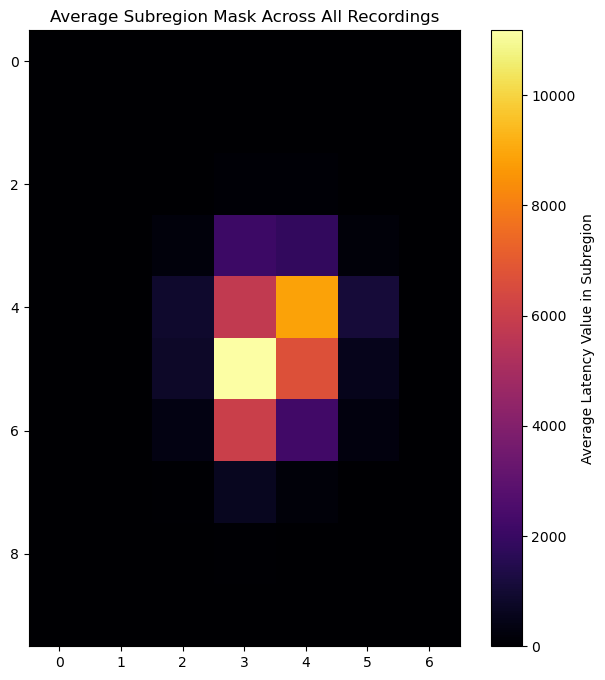

In [38]:
# shape analysis of subregions
# 1) convert to 8-connected graph 
# 2) extract graph features: degree distribution, endpoints, branch points, and diameter
# 3) also compute regionprops features like eccentricity, solidity, perimeter, major/minor axis length, and orientation
# 4) clustering on graph features and regionprops features to see if there are distinct subregion shapes

def build_graph(mask):
    """
    Build an 8-connected graph from a binary mask.
    Nodes = pixel coordinates
    Edges = 8-neighborhood adjacency
    """
    G = nx.Graph()
    rows, cols = np.where(mask > 0)
    pixels = list(zip(rows, cols))
    
    for r, c in pixels:
        G.add_node((r, c))
    
    for r, c in pixels:
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                neighbor = (r + dr, c + dc)
                if neighbor in G:
                    G.add_edge((r, c), neighbor)
    
    return G

def canonical_hash(G):
    """
    Compute canonical hash for graph structure.
    Groups exact topological motifs.
    """
    # Relabel nodes to integers
    G2 = nx.convert_node_labels_to_integers(G)
    
    # Canonical adjacency matrix
    A = nx.to_numpy_array(G2)
    
    # Sort by degree sequence 
    degrees = np.sum(A, axis=1)
    idx = np.argsort(degrees)
    A_sorted = A[idx][:, idx]
    
    # Hash matrix
    h = hashlib.md5(A_sorted.tobytes()).hexdigest()
    return h

def extract_features(G, mask):
    """
    Extract structural and geometric features.
    Returns a numeric feature vector.
    """
    features = []
    
    # Basic
    area = G.number_of_nodes()
    features.append(area)
    
    degrees = [d for _, d in G.degree()]
    
    # Degree histogram (cap at 4+)
    for k in [1, 2, 3]:
        features.append(degrees.count(k))
    features.append(sum(d >= 4 for d in degrees))
    
    # Endpoints and branch points
    endpoints = sum(d == 1 for d in degrees)
    branchpoints = sum(d >= 3 for d in degrees)
    features.append(endpoints)
    features.append(branchpoints)
    
    # Connected components
    features.append(nx.number_connected_components(G))
    
    # Diameter (if connected)
    if nx.is_connected(G):
        features.append(nx.diameter(G))
    else:
        features.append(0)
    
    # Euler characteristic
    '''edges = G.number_of_edges()
    nodes = G.number_of_nodes()
    components = nx.number_connected_components(G)
    euler = nodes - edges + components
    features.append(euler)'''
    
    # Bounding box aspect ratio
    '''props = regionprops(mask.astype(int))
    if props:
        minr, minc, maxr, maxc = props[0].bbox
        width = maxc - minc
        height = maxr - minr
        aspect = width / height if height > 0 else 0
    else:
        aspect = 0
    features.append(aspect)'''

    # area 
    area = np.sum(mask)
    features.append(area)
    
    return np.array(features)



average_subregion_mask = np.zeros((80, 80))  # assuming 80x80 maps, will average binary masks of subregions into this for visualization
subregion_mask_list = []  # keep list of subregion masks for clustering analysis later
subregion_velocity_features = []  # list of (x_velocity, y_velocity, x_velocity_std, y_velocity_std) for clustering analysis later
from skimage.measure import regionprops
subregion_velocities_df['Eccentricity'] = np.nan
subregion_velocities_df['Solidity'] = np.nan
subregion_velocities_df['Perimeter'] = np.nan
subregion_velocities_df['Major_Axis'] = np.nan
subregion_velocities_df['Minor_Axis'] = np.nan
subregion_velocities_df['Orientation'] = np.nan
for date in ppr_df['Date'].unique():
    date_df = ppr_df[ppr_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            for recording in location_df['Recording'].unique():
                recording_df = location_df[location_df['Recording'] == recording]

                n_roi_stats_key = f'{date}_{slic}_{location}_{recording}'
                if n_roi_stats_key in n_roi_keys_to_skip:
                    continue
                n_roi_keys_to_skip.append(n_roi_stats_key)  # add to skip list to avoid re-processing in future

                # find the corresponding lat_map and amp_map files
                lat_map_file = recording_df.iloc[0]['latency_array']
                amp_map_file = recording_df.iloc[0]['amp_array']
                stim_time = recording_df.iloc[0]['stim_time']
                lat_map = read_array_file(lat_map_file) - stim_time
                amp_map = read_array_file(amp_map_file)

                # find subregion files corresponding to this recording
                subregion_file = subregion_velocities_df[subregion_velocities_df['subregion_file'].str.contains(n_roi_stats_key)]['subregion_file'].unique()
                if len(subregion_file) == 0:
                    continue
                subregions_list = ROIFileReader(subregion_file[0]).get_roi_list()

                for subregion in subregions_list:
                    # create binary mask of subregion
                    mask = np.zeros_like(lat_map, dtype=bool)
                    for px in subregion:
                        mask[px[1], px[0]] = lat_map[px[1], px[0]]  # use latency values in mask for regionprops analysis
                    # compute regionprops
                    props = regionprops(mask.astype(int))
                    if len(props) > 0:
                        prop = props[0]
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Eccentricity'] = prop.eccentricity
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Solidity'] = prop.solidity
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Perimeter'] = prop.perimeter
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Major_Axis'] = prop.major_axis_length
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Minor_Axis'] = prop.minor_axis_length
                        # angle of major axis in degrees
                        subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'Orientation'] = prop.orientation * 180 / np.pi

                    # rotate mask to align major axis with x axis for averaging
                    if len(props) > 0:
                        prop = props[0]
                        angle_rad = -prop.orientation  # negative to rotate in opposite direction
                        rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)], 
                                                    [np.sin(angle_rad), np.cos(angle_rad)]])
                        coords = np.column_stack(np.where(mask))
                        center_of_mass = prop.centroid
                        centered_coords = coords - center_of_mass
                        rotated_coords = centered_coords @ rotation_matrix.T
                        rotated_coords += center_of_mass
                        rotated_mask = np.zeros_like(mask)
                        for rc in rotated_coords.astype(int):
                            if 0 <= rc[0] < mask.shape[0] and 0 <= rc[1] < mask.shape[1]:
                                rotated_mask[rc[0], rc[1]] = mask[int(rc[0]), int(rc[1])]
                    # trim mask to bounding box of region and save to file for later analysis
                    min_row, min_col, max_row, max_col = prop.bbox
                    trimmed_mask = rotated_mask[min_row:max_row, min_col:max_col]

                    # add trimmed mask to center of average_subregion_mask for visualization
                    center_y = average_subregion_mask.shape[0] // 2
                    center_x = average_subregion_mask.shape[1] // 2
                    mask_height, mask_width = trimmed_mask.shape
                    start_y = center_y - mask_height // 2
                    start_x = center_x - mask_width // 2
                    average_subregion_mask[start_y:start_y+mask_height, start_x:start_x+mask_width] += (trimmed_mask > 0)  # only count non-zero pixels
                    subregion_mask_list.append(trimmed_mask)
                    x_velocity = subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'x_velocity']
                    y_velocity = subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'y_velocity']
                    x_velocity_std = subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'x_velocity_std']
                    y_velocity_std = subregion_velocities_df.at[f'{n_roi_stats_key}_subregion_{subregions_list.index(subregion)}', 'y_velocity_std']
                    subregion_velocity_features.append((x_velocity, y_velocity, x_velocity_std, y_velocity_std))
                # garbage collect
                del lat_map, amp_map, subregions_list

# show average subregion mask
# crop average_subregion_mask to non-zero region for better visualization
non_zero_indices = np.argwhere(average_subregion_mask > 0)
min_row, min_col = non_zero_indices.min(axis=0)
max_row, max_col = non_zero_indices.max(axis=0) + 1  # +1 to include the max index
cropped_mask = average_subregion_mask[min_row:max_row, min_col:max_col]
plt.figure(figsize=(8, 8))
plt.imshow(cropped_mask, cmap='inferno')
plt.colorbar(label='Average Latency Value in Subregion')
plt.title('Average Subregion Mask Across All Recordings')
plt.savefig(output_fig_dir + 'average_subregion_mask.png')
plt.show()


# save to new file
subregion_velocities_df.to_csv(output_fig_dir + 'subregion_velocities_attributes.csv')

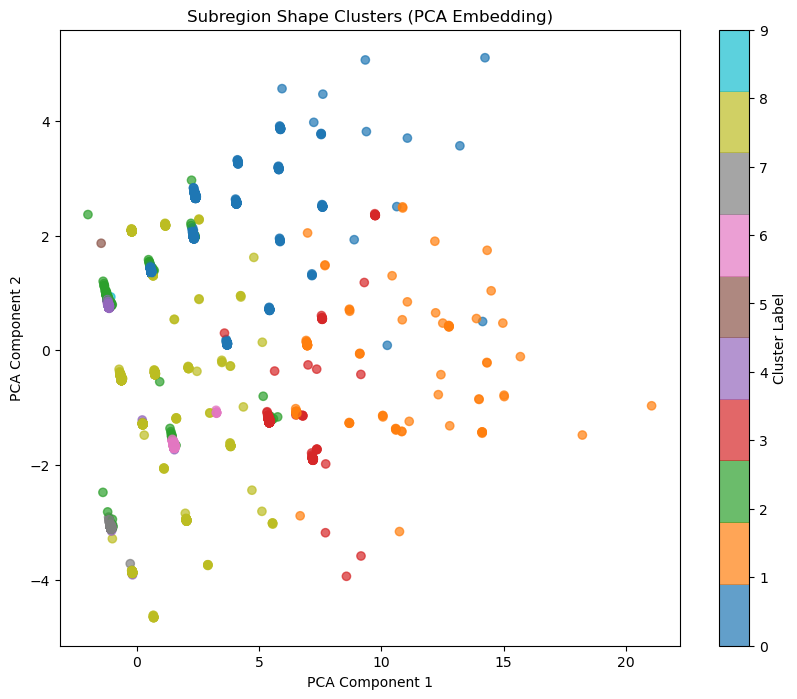

In [39]:
def process_dataset(masks, velocity_features=None):
    """
    masks = list of binary numpy arrays
    velocity_features = list of (x_velocity, y_velocity, x_velocity_std, y_velocity_std) tuples
    """
    hashes = []
    features = []
    
    for i, mask in enumerate(masks):
        # skip empty masks or masks with only 1 pixel
        if np.sum(mask) <= 1:
            continue
        G = build_graph(mask)
        
        h = canonical_hash(G)
        hashes.append(h)
        
        f = extract_features(G, mask)
        if velocity_features is not None:
            f = np.append(f, velocity_features[i])
        features.append(f)
    
    features = np.vstack(features)
    return hashes, features

def cluster_features(feature_matrix, n_clusters=5):
    scaler = StandardScaler()
    X = scaler.fit_transform(feature_matrix)
    
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clusterer.fit_predict(X)
    
    return labels

def visualize_embedding(features):
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    
    return X2

hashes, features = process_dataset(subregion_mask_list, velocity_features=subregion_velocity_features)

# Exact motif counts
from collections import Counter
motif_counts = Counter(hashes)

# Cluster approximate similarities
labels = cluster_features(features, n_clusters=10)

# 2D embedding
embedding = visualize_embedding(features)

visualize_embedding(features)
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.title('Subregion Shape Clusters (PCA Embedding)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.savefig(output_fig_dir + 'subregion_shape_clusters.png')
plt.show()

Cluster 0 - Motif 1: Hash=cddbfb5b38987786a6ecd106bea6e664, Count=11
  Mean Features: [ 6.          3.          2.          1.          0.          3.
  1.          1.          4.          6.         19.8688043  47.24278607
 81.07212518 68.61967992]


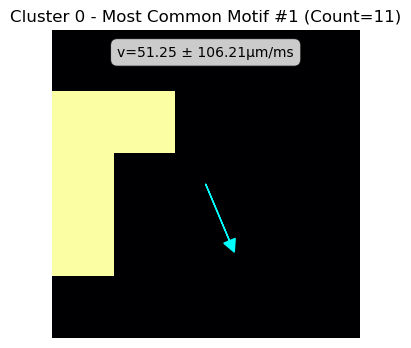

Cluster 0 - Motif 2: Hash=885a5090c529e81d71622af8b313dda2, Count=6
  Mean Features: [   5.            3.            1.            1.            0.
    3.            1.            1.            3.            5.
    3.3992038  -101.09332515   58.72124211   83.41761287]


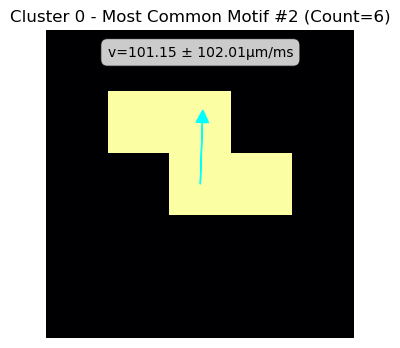

Cluster 0 - Motif 3: Hash=da2bee59d7c11cd352f7e330c667365b, Count=3
  Mean Features: [   6.            3.            2.            1.            0.
    3.            1.            1.            4.            6.
 -115.03032063    2.87703958  101.18258777   55.02650926]


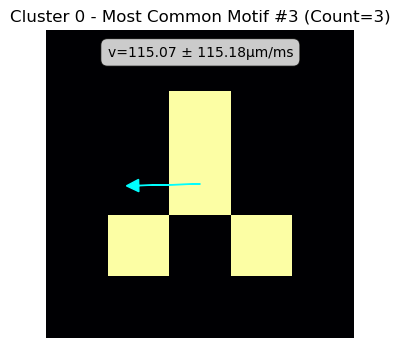

Cluster 1 - Motif 1: Hash=231da1d2fa6ddce23bddca8d04ba0777, Count=2
  Mean Features: [ 6.          1.          0.          3.          2.          1.
  5.          1.          3.          6.         27.89657471 54.78765742
 33.6842993  29.31547266]


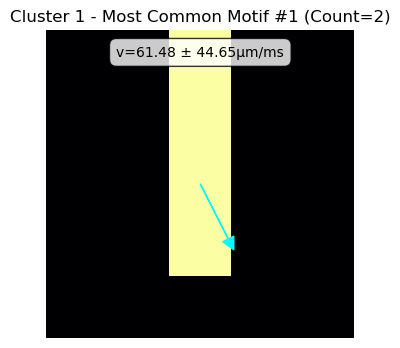

Cluster 3 - Motif 1: Hash=944eaeaa33a1531325952e39829120d3, Count=1
  Mean Features: [  8.           2.           2.           2.           0.
   2.           2.           4.           0.           8.
 -12.28594728  72.02255603  34.73334584  57.81774206]


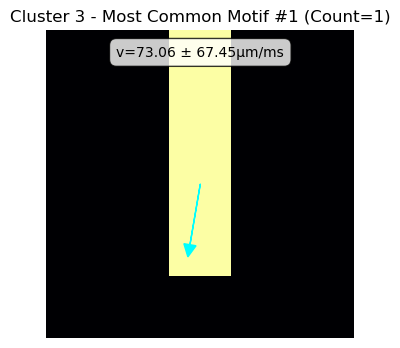

Cluster 8 - Motif 1: Hash=f9a2651c3b53b53c5bd0238429df8f54, Count=43
  Mean Features: [   4.            0.            3.            0.            0.
    0.            0.            2.            0.            4.
 -147.76386313   40.17260133   65.22882538   69.10012742]


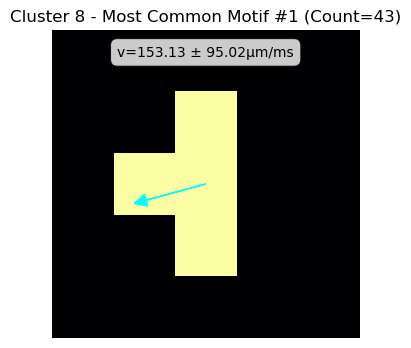

Cluster 8 - Motif 2: Hash=83a0e7a9799dd4b5c8d628118b61c11b, Count=11
  Mean Features: [5.00000000e+00 4.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 4.00000000e+00 0.00000000e+00 2.00000000e+00
 0.00000000e+00 5.00000000e+00 2.55466402e+02 1.41426982e+03
 7.50229419e+01 8.35355477e+01]


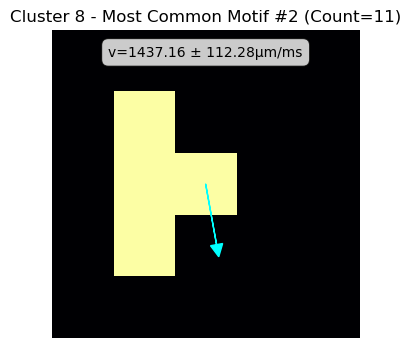

In [40]:
# for each cluster, show most common motif and average feature values
cluster_info = {}
n_motifs_to_track = 20
min_per_motif_count = 1  # only consider motifs that appear at least this many times in the cluster
min_px_per_motif = 4  # only consider motifs that have at least this many pixels in their mask to exclude single-pixel motifs

for cluster in np.unique(labels):
    cluster_indices = np.where(labels == cluster)[0]
    cluster_hashes = [hashes[i] for i in cluster_indices]
    j = 0
    for motif, count in Counter(cluster_hashes).most_common(n_motifs_to_track):
        # exclude if motif only appears less than min_per_motif_count in cluster or is only one pixel
        if  count < min_per_motif_count:
            continue
        motif_mask = None
        for i, h in enumerate(hashes):
            if h == motif:
                motif_mask = subregion_mask_list[i]
                break
        if motif_mask is not None and np.sum(motif_mask) < min_px_per_motif:
            continue
        motif_indices = [i for i, h in enumerate(hashes) if h == motif]
        motif_features = features[motif_indices]
        mean_features = np.mean(motif_features, axis=0)
        
        if cluster not in cluster_info:
            cluster_info[cluster] = {}
        cluster_info[cluster][j] = {
            'motif_hash': motif,
            'motif_count': count,
            'mean_features': mean_features
        }
        j += 1
# print cluster info
for cluster, info in cluster_info.items():
    # plot most common motifs for this cluster
    for j in info:
        motif_info = info[j]
        motif = motif_info['motif_hash']
        count = motif_info['motif_count']
        print(f"Cluster {cluster} - Motif {j+1}: Hash={motif}, Count={count}")
        print(f"  Mean Features: {motif_info['mean_features']}")
        # exclude motifs that only appear once in the cluster or are only one pixel
        motif_mask = None
        for i, h in enumerate(hashes):
            if h == motif:
                motif_mask = subregion_mask_list[i]
                break
        if motif_mask is not None:
            # pad motif mask to 5x5 for better visualization
            padded_mask = np.zeros((5, 5))
            w, h = motif_mask.shape
            if w > 5 or h > 5:
                padded_mask = motif_mask  # if motif is larger than 5x5, just use original mask without padding
            else:
                # centered in padded mask
                padded_mask[2 - w//2:2 - w//2 + w, 2 - h//2:2 - h//2 + h] = motif_mask
            plt.figure(figsize=(4, 4))
            plt.imshow(padded_mask, cmap='inferno')
            plt.title(f'Cluster {cluster} - Most Common Motif #{j+1} (Count={count})')
            # from mean features get velocity features and annotate on plot 
            mean_features = motif_info['mean_features']
            # assuming velocity features are the last 4 elements of mean_features
            x_vel, y_vel, x_vel_std, y_vel_std = mean_features[-4:]
            # draw direction of velocity vector on plot and annotate speed values
            speed = np.sqrt(x_vel**2 + y_vel**2)
            plt.arrow(2, 2, x_vel/speed if speed > 0 else 0, y_vel/speed if speed > 0 else 0, head_width=0.2, head_length=0.2, fc='cyan', ec='cyan')
            plt.annotate(f'v={speed:.2f} ± {np.sqrt(x_vel_std**2 + y_vel_std**2):.2f}μm/ms', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
            plt.axis('off')
            plt.savefig(output_fig_dir + f'cluster_{cluster}_most_common_motif.png')
            plt.show()

Layer L2/3 - Mean Eccentricity: 0.88, Mean Solidity: 0.75, Mean Perimeter: 3.85, Mean Major Axis: 4.67, Mean Minor Axis: 1.71, Mean Orientation: 4.39 degrees


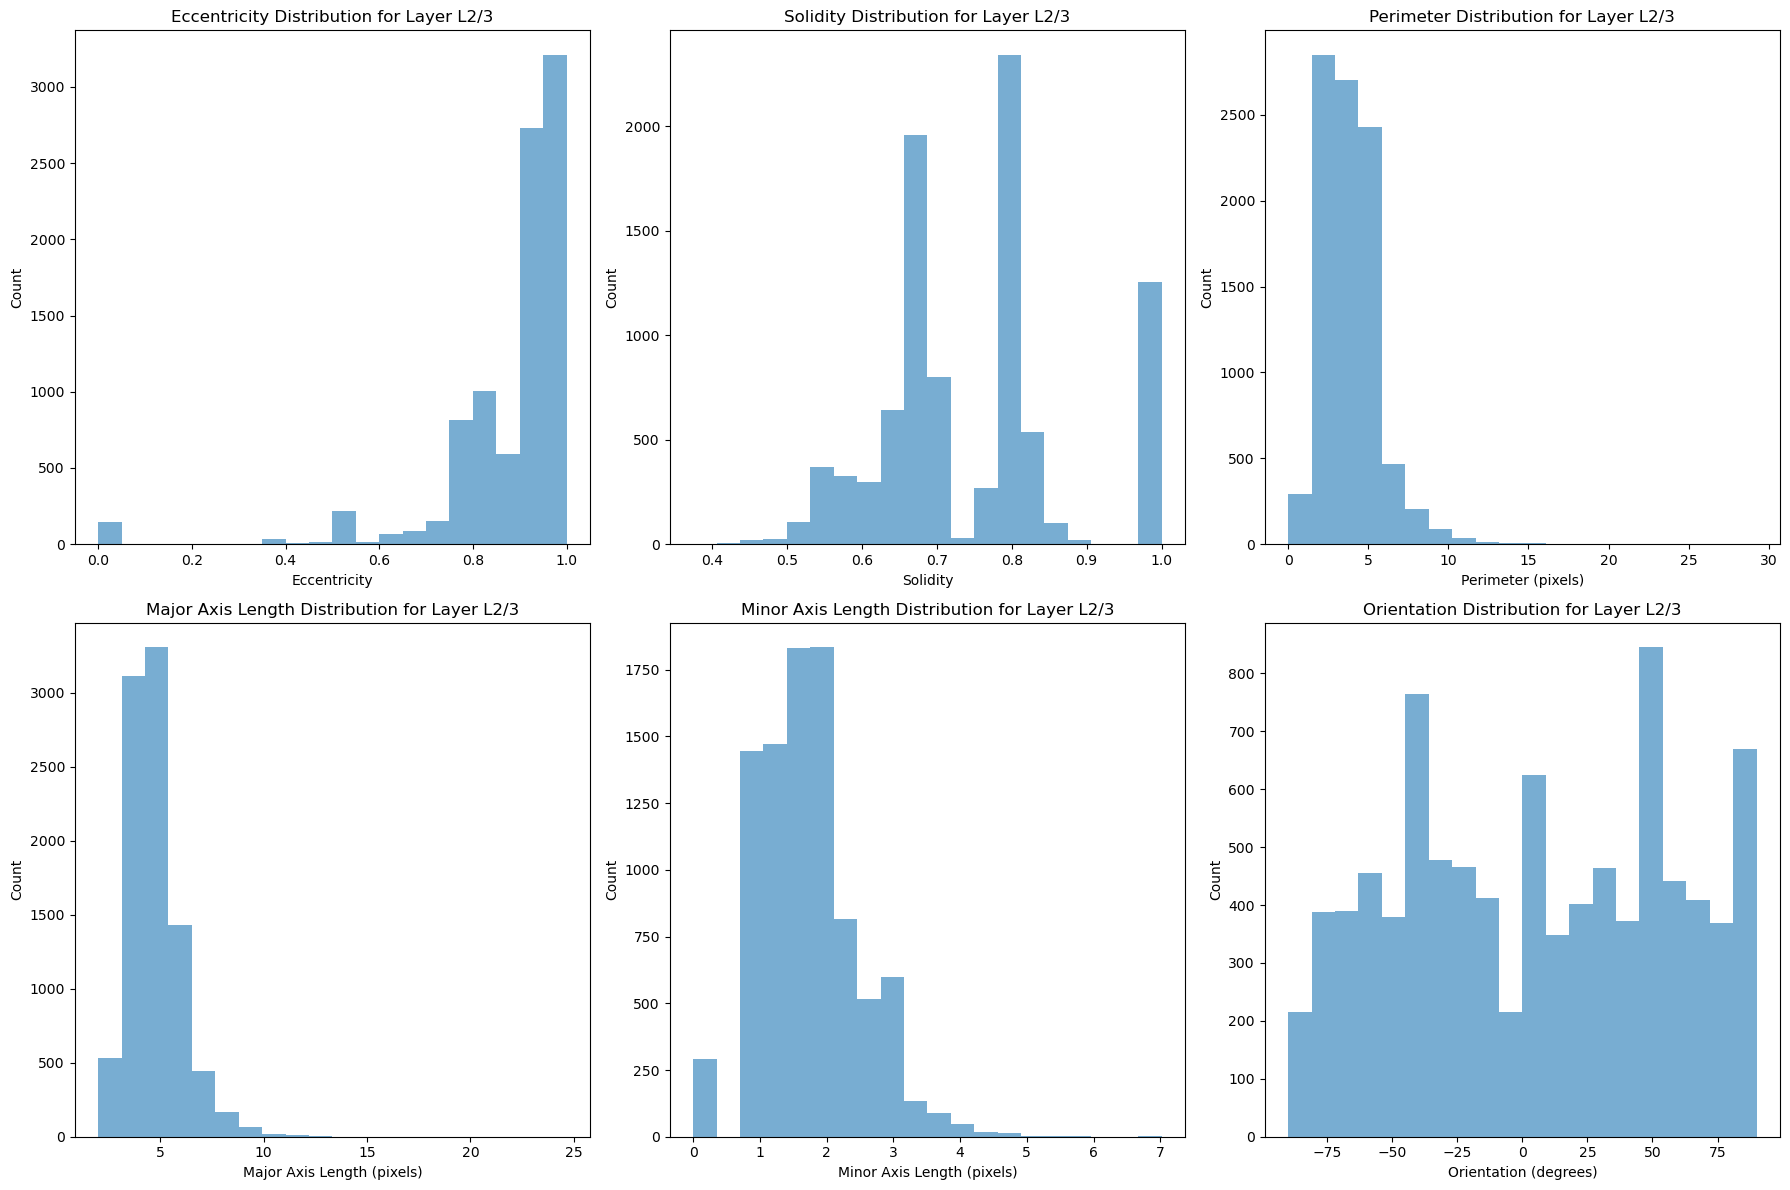

Layer L4 - Mean Eccentricity: 0.88, Mean Solidity: 0.75, Mean Perimeter: 3.83, Mean Major Axis: 4.67, Mean Minor Axis: 1.71, Mean Orientation: 6.82 degrees


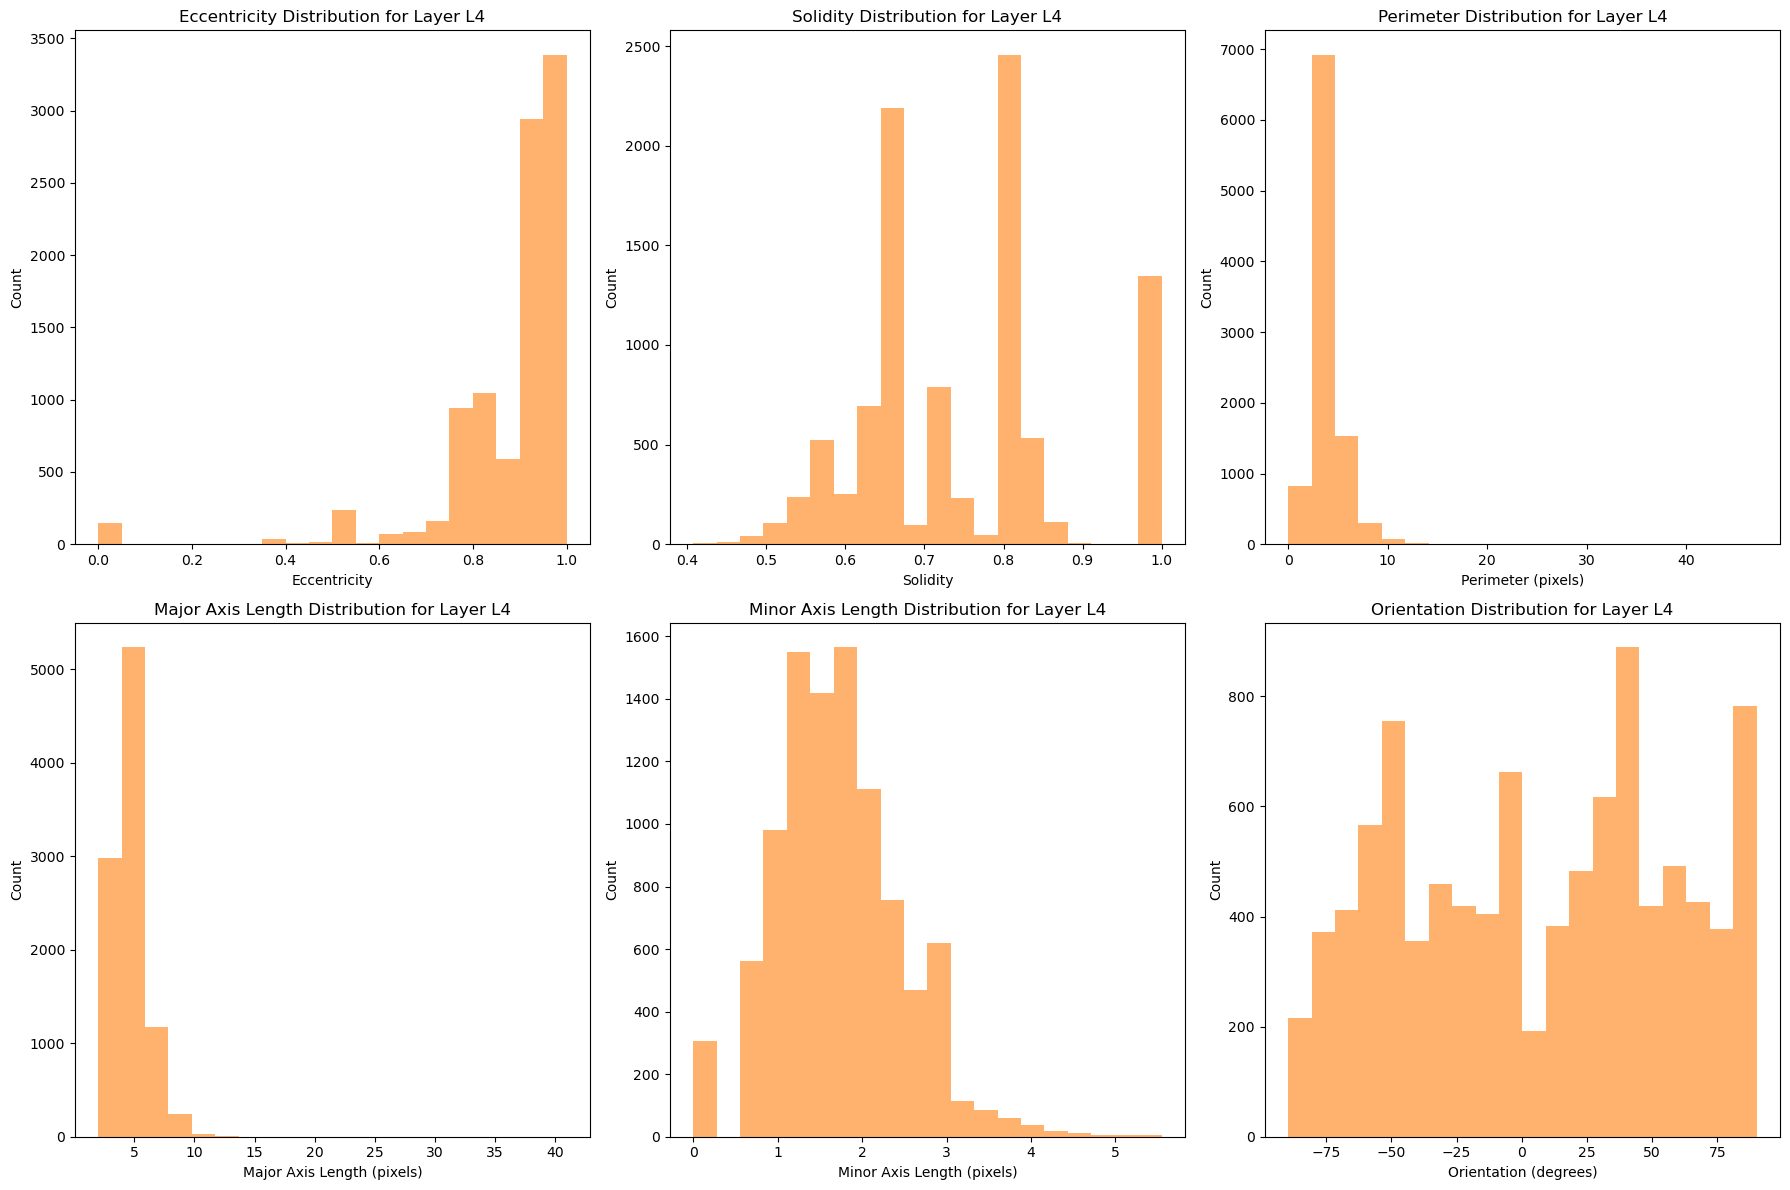

Layer L5 - Mean Eccentricity: 0.88, Mean Solidity: 0.75, Mean Perimeter: 3.80, Mean Major Axis: 4.66, Mean Minor Axis: 1.71, Mean Orientation: 5.92 degrees


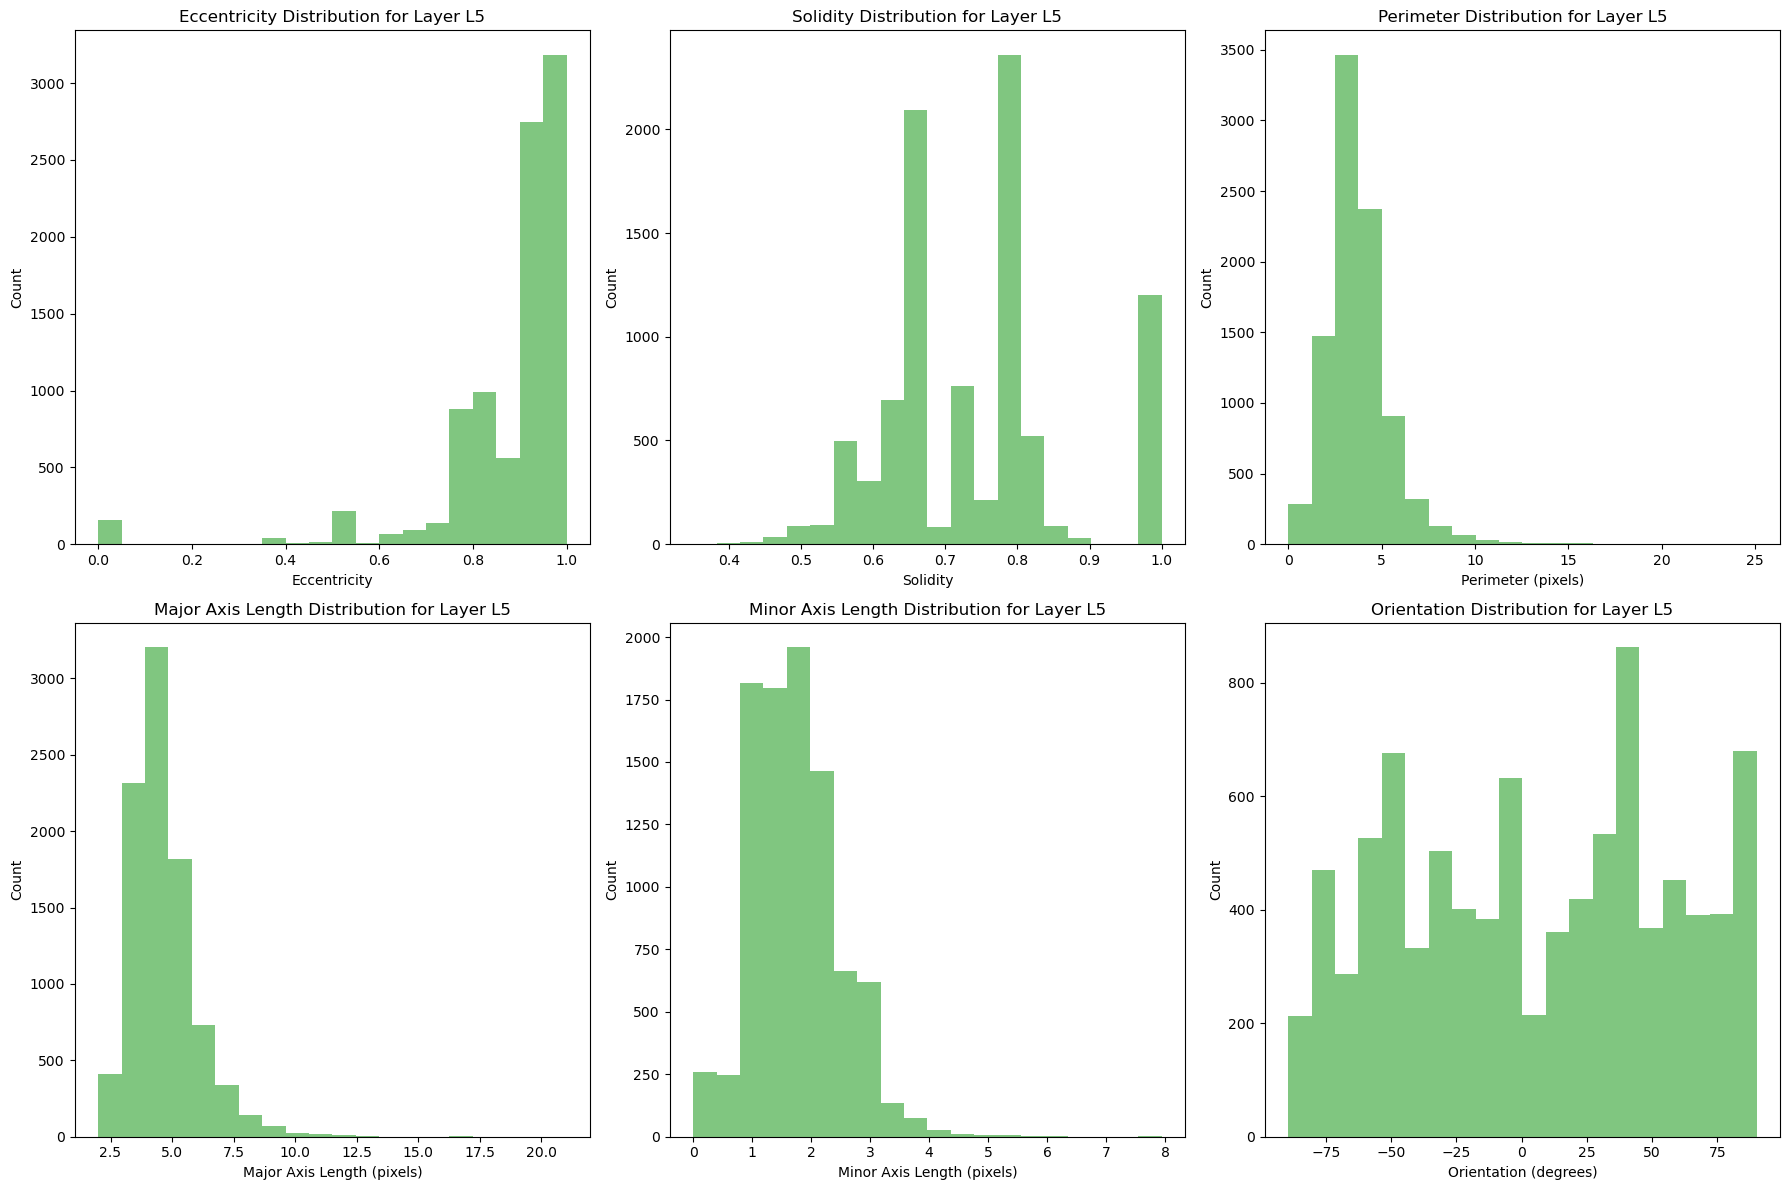

In [41]:
# print mean eccentricity, solidity, perimeter, major axis, minor axis, and orientation of subregions grouped by stimulated layer
for layer in layers:
    layer_df = subregion_velocities_df[subregion_velocities_df['Layer'] == layer]
    mean_eccentricity = layer_df['Eccentricity'].mean()
    mean_solidity = layer_df['Solidity'].mean()
    mean_perimeter = layer_df['Perimeter'].mean()
    mean_major_axis = layer_df['Major_Axis'].mean()
    mean_minor_axis = layer_df['Minor_Axis'].mean()
    mean_orientation = layer_df['Orientation'].mean()
    print(f'Layer {layer} - Mean Eccentricity: {mean_eccentricity:.2f}, Mean Solidity: {mean_solidity:.2f}, Mean Perimeter: {mean_perimeter:.2f}, Mean Major Axis: {mean_major_axis:.2f}, Mean Minor Axis: {mean_minor_axis:.2f}, Mean Orientation: {mean_orientation:.2f} degrees')

    # show histogram of each shape metric for this layer
    plt.figure(figsize=(18, 12))
    plt.subplot(2, 3, 1)
    plt.hist(layer_df['Eccentricity'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Eccentricity Distribution for Layer {layer}')
    plt.xlabel('Eccentricity')
    plt.ylabel('Count')
    plt.subplot(2, 3, 2)
    plt.hist(layer_df['Solidity'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Solidity Distribution for Layer {layer}')
    plt.xlabel('Solidity')
    plt.ylabel('Count')
    plt.subplot(2, 3, 3)
    plt.hist(layer_df['Perimeter'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Perimeter Distribution for Layer {layer}')
    plt.xlabel('Perimeter (pixels)')
    plt.ylabel('Count')
    plt.subplot(2, 3, 4)
    plt.hist(layer_df['Major_Axis'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Major Axis Length Distribution for Layer {layer}')
    plt.xlabel('Major Axis Length (pixels)')
    plt.ylabel('Count')
    plt.subplot(2, 3, 5)
    plt.hist(layer_df['Minor_Axis'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Minor Axis Length Distribution for Layer {layer}')
    plt.xlabel('Minor Axis Length (pixels)')
    plt.ylabel('Count')
    plt.subplot(2, 3, 6)
    plt.hist(layer_df['Orientation'].dropna(), bins=20, color=colors[layer], alpha=0.6)
    plt.title(f'Orientation Distribution for Layer {layer}')
    plt.xlabel('Orientation (degrees)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(output_fig_dir + f'subregion_shape_histograms_layer{layer.replace("/", "")}.png')
    plt.show()
    

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scala

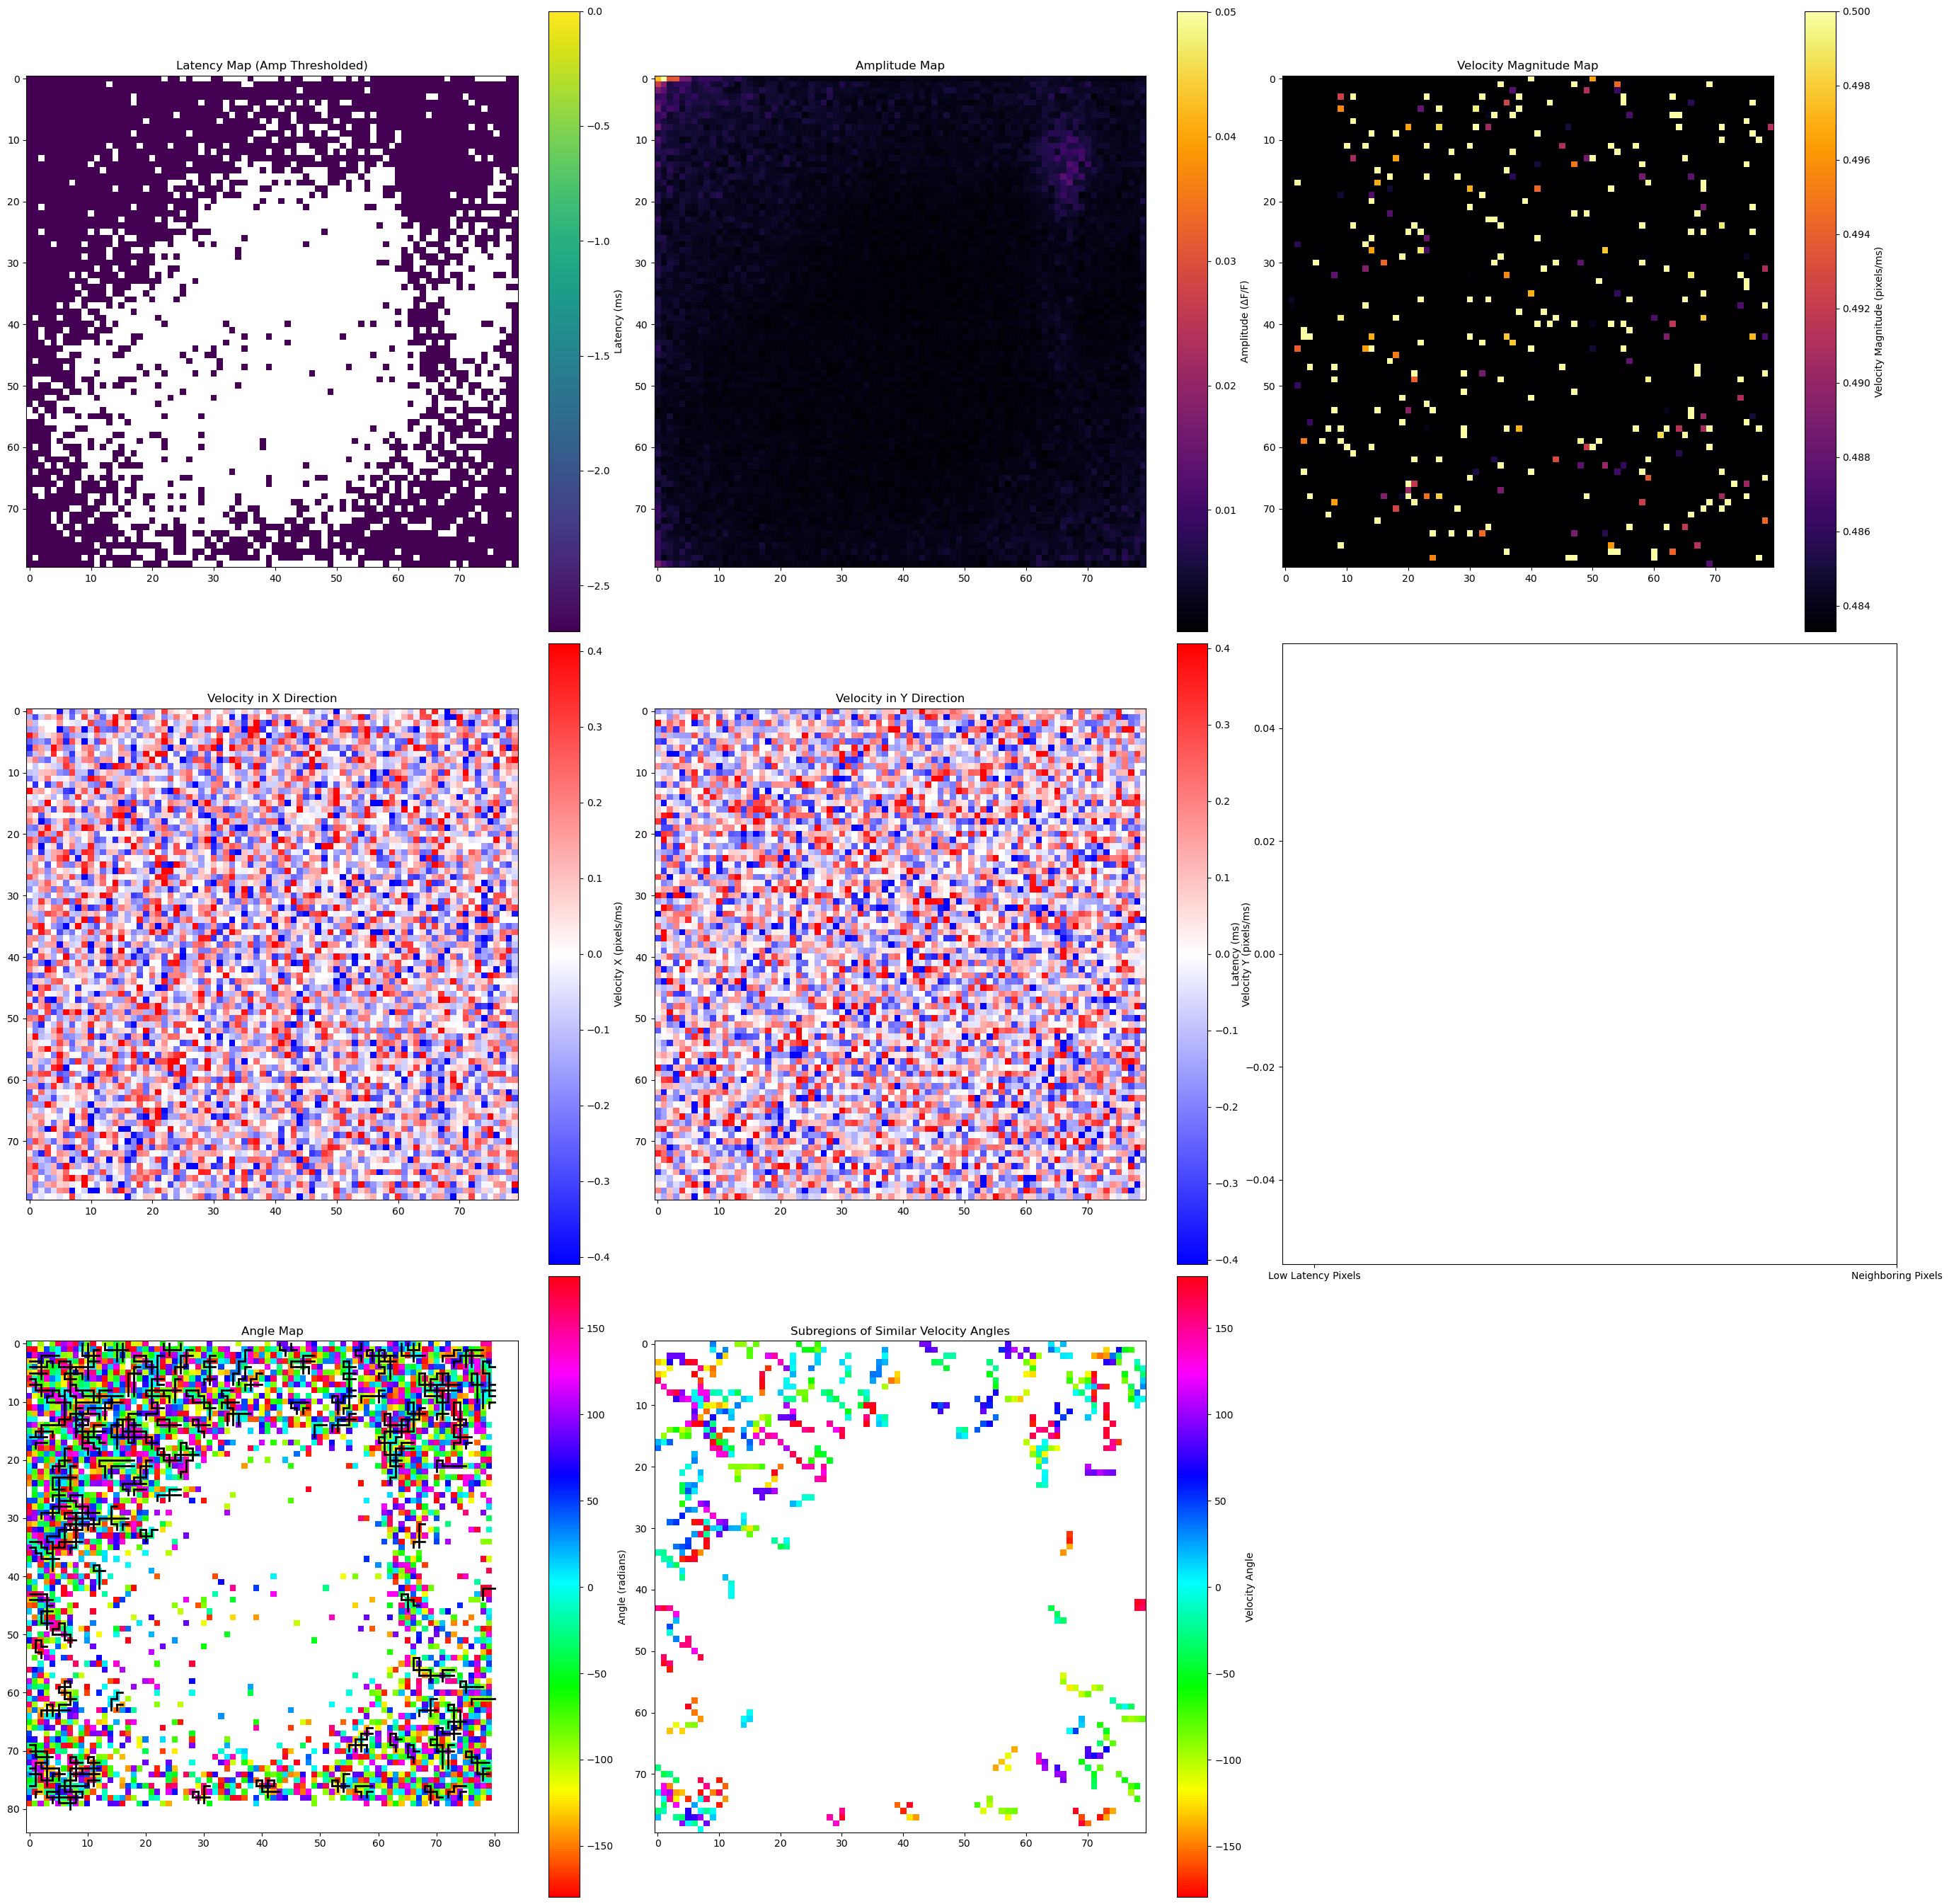

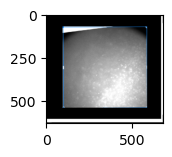

In [ ]:
# mCherry example 2/20/24, 02_01_01
use_mCherry_example = True
if use_mCherry_example:
    example_data_dir = 'C:/Users/jjudge3/Desktop/Data/PV-PPR/mCherry-PV/'
    example_lat_map_file = example_data_dir + '02-20-24/zda/_02_01_01_latency_array_.dat'
    example_amp_map_file = example_data_dir + '02-20-24/zda/_02_01_01_amp_array_.dat'
    example_stim_time = 49.250165289256195
    xth_percentile = 50
    lat_map = read_array_file(example_lat_map_file) - example_stim_time
    amp_map = read_array_file(example_amp_map_file)
    mCherry_img = example_data_dir + '02-20-24/2-1r.png'

    lat_map_masked, velocity_magnitude, velocity_x, velocity_y = \
        compute_velocity_maps(lat_map, amp_map, xth_percentile=xth_percentile, bin_size=1, bin_size_velocities=1)

    compute_low_latency_and_vector_sim_subregions(output_fig_dir + f'low_latency_and_vector_similarity_subregions_mCherry_example.png',
                                                  amp_map,
        lat_map_masked, velocity_x, velocity_y, amp_threshold_percentile=50,
        similarity_metric='angle_difference', show_plots=True, close_plots=False)

    plt.subplot(3, 3, 9)
    # open and show mCherry image
    mCherry_img = plt.imread(mCherry_img)
    plt.imshow(mCherry_img)
    plt.show()

In [43]:
# 3-way ANOVA tests for PPR across IPI, Stim_Loc, and ROI_Loc
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for metric in ['PPHW', 'PPR', 'PPL']:
    for hn in ['Home', 'Neighbor']:
        hn_df = ppr_df[ppr_df['Home_Neighbor'] == hn]

        # filter nan from hn_df
        hn_df = hn_df.dropna(subset=[metric, 'IPI', 'Stim_Layer', 'HN_ROI_Loc'])
        
        model = ols(f'{metric} ~ C(IPI) + C(Stim_Layer) + C(HN_ROI_Loc) + C(IPI):C(Stim_Layer) + C(IPI):C(HN_ROI_Loc) + C(Stim_Layer):C(HN_ROI_Loc)', data=hn_df).fit()
        anova_table = anova_lm(model, typ=2)
        print(f"ANOVA results for {metric} {hn}:")
        print(anova_table)
        
        # significant differences to further test
        sig_diffs = {
            'Home': ['IPI', 'Stim_Layer', 'HN_ROI_Loc', 'Stim_Layer:HN_ROI_Loc'],
            'Neighbor': ['Stim_Layer', 'IPI:Stim_Layer', 'IPI:HN_ROI_Loc']
        }
        for s_diff in sig_diffs[hn]:
            print(f"Tukey's HSD test for {s_diff} in {hn}:")
            if ':' not in s_diff:
                # Tukey's HSD test for multiple comparisons
                
                tukey = pairwise_tukeyhsd(endog=hn_df[metric],
                                        groups=hn_df[s_diff], alpha=0.05)
                print(tukey)
            else:
                # double interaction terms require different handling
                # make a column that is the two columns appended
                cols = s_diff.split(':')
                hn_df[s_diff] = hn_df[cols[0]].astype(str) + "_" + hn_df[cols[1]].astype(str)
                # make nested groups for Tukey
                tukey = pairwise_tukeyhsd(endog=hn_df[metric],
                                        groups=hn_df[s_diff], alpha=0.05)
                print(tukey)

    model = ols(f'{metric} ~ C(IPI) + C(Stim_Layer) + C(HN_ROI_Loc) + C(IPI):C(Stim_Layer) + C(IPI):C(HN_ROI_Loc) + C(Stim_Layer):C(HN_ROI_Loc)', data=ppr_df).fit()
    anova_table = anova_lm(model, typ=2)
    print(f"ANOVA results for metric {metric} both:")
    print(anova_table)


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 6
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '


ANOVA results for PPHW Home:
                                   sum_sq      df          F        PR(>F)
C(IPI)                          89.159879     9.0   0.872826  5.139006e-01
C(Stim_Layer)                  505.322696     2.0  22.260733  2.426537e-10
C(HN_ROI_Loc)                  129.161304     2.0   5.689880  3.407049e-03
C(IPI):C(Stim_Layer)           909.866565    18.0   4.453545  5.287612e-08
C(IPI):C(HN_ROI_Loc)           488.760445    18.0   2.392347  8.214421e-04
C(Stim_Layer):C(HN_ROI_Loc)    860.444373     4.0  18.952367  1.872290e-15
Residual                     46013.269560  4054.0        NaN           NaN
Tukey's HSD test for IPI in Home:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  20.0   30.0  -0.7745    0.9  -5.6637  4.1147  False
  20.0   40.0  -0.0813    0.9  -4.9705  4.8079  False
  20.0   50.0  -1.2953  0.001  -1.7607   -0.83   True
  20.0   60.0

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '


ANOVA results for PPHW Neighbor:
                                    sum_sq      df          F        PR(>F)
C(IPI)                         6620.817146     9.0  40.809697  2.041794e-41
C(Stim_Layer)                   269.259129     2.0   7.468523  5.761503e-04
C(HN_ROI_Loc)                   231.884648     2.0   6.431856  1.620701e-03
C(IPI):C(Stim_Layer)            983.778032    18.0   3.031928  1.092235e-04
C(IPI):C(HN_ROI_Loc)            604.500691    18.0   1.863025  1.457042e-02
C(Stim_Layer):C(HN_ROI_Loc)     438.322055     4.0   6.078937  7.050717e-05
Residual                     107003.900501  5936.0        NaN           NaN
Tukey's HSD test for Stim_Layer in Neighbor:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  L2/3     L4  -0.1387  0.579 -0.4682 0.1908  False
  L2/3     L5   0.3246 0.0575 -0.0079 0.6571  False
    L4     L5   0.4633 0.0019  0.1443 0.7823   True
--

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 45, but rank is 44
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints doe

...

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 45, but rank is 44
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints doe

ANOVA results for PPL Home:
                                   sum_sq      df          F        PR(>F)
C(IPI)                         653.618332     9.0  26.236357  9.410726e-31
C(Stim_Layer)                   16.192696     2.0   2.924900  5.379091e-02
C(HN_ROI_Loc)                    4.662881     2.0   0.842260  4.308164e-01
C(IPI):C(Stim_Layer)           140.865261    18.0   2.827178  3.120192e-04
C(IPI):C(HN_ROI_Loc)            53.277009    18.0   1.069274  3.772624e-01
C(Stim_Layer):C(HN_ROI_Loc)     27.683876     4.0   2.500280  4.058613e-02
Residual                     10518.692852  3800.0        NaN           NaN
Tukey's HSD test for IPI in Home:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  20.0   30.0   0.3811    0.9 -2.6808 3.4429  False
  20.0   40.0   0.6132    0.9 -2.0398 3.2663  False
  20.0   50.0   0.4108  0.001  0.1717 0.6499   True
  20.0   60.0   1.4123    

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
100.0_L2/3   100.0_L4  -0.0827    0.9 -0.4987  0.3334  False
100.0_L2/3   100.0_L5    0.233    0.9 -0.1852  0.6512  False
100.0_L2/3 150.0_L2/3   2.5805  0.001   0.982   4.179   True
100.0_L2/3   150.0_L4  -0.6406    0.9 -2.3327  1.0515  False
100.0_L2/3   150.0_L5  -0.8356    0.9 -2.4342  0.7629  False
100.0_L2/3  20.0_L2/3   -1.739  0.001 -2.2314 -1.2466   True
100.0_L2/3    20.0_L4  -1.3446  0.001 -1.7925 -0.8968   True
100.0_L2/3    20.0_L5   -1.217  0.001 -1.6761  -0.758   True
100.0_L2/3 200.0_L2/3  -0.1667    0.9 -0.6556  0.3221  False
100.0_L2/3   200.0_L4  -0.2802 0.8388 -0.7472  0.1868  False
100.0_L2/3   200.0_L5   -0.058    0.9 -0.5326  0.4167  False
100.0_L2/3    30.0_L4  -2.1868 0.5269 -5.1801  0.8064  False
100.0_L2/3    40.0_L4   -2.163 0.1308 -4.5367  0.2106  False
100.0_L2/3  50.0_L2/3  -

c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 14
  warnings.warn('covariance of constraints does not have full '
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\statsmodels\base\model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 45, but rank is 44
  warnings.warn('covariance of constraints does not have full '


In [44]:
# save final dataframe to CSV
output_csv = output_fig_dir + 'ppr_analysis_raw_data.csv'
ppr_df.to_csv(output_csv, index=False)

In [45]:
# 2-way ANOVA for medial and lateral PPR vs IPI (coronal sections)
model = ols('PPR ~ IPI + C(Medial_Lateral) + IPI:C(Medial_Lateral)', 
                data=ppr_df[(ppr_df['Medial_Lateral'] != 'Home') & (ppr_df['Section'] == 'Coronal')]).fit()
anova_table = anova_lm(model, typ=2)
anova_table

KeyError: 'Medial_Lateral'

In [ ]:
# 2-way ANOVA for rostral and caudal PPR vs IPI (sagittal sections)
model = ols('PPR ~ IPI + C(Rostral_Caudal) + IPI:C(Rostral_Caudal)', 
                data=ppr_df[(ppr_df['Rostral_Caudal'] != 'Home') & (ppr_df['Section'] == 'Sagittal')]).fit()
anova_table = anova_lm(model, typ=2)
anova_table

In [ ]:
# 2-way ANOVA for coronal and sagittal PPR vs IPI (all sections)
model = ols('PPR ~ IPI + C(Section) + IPI:C(Section)', 
                data=ppr_df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

In [ ]:
# load all_animals_age_sex.csv from C:\Users\jjudge3\Desktop\Data\crossing_PPR\
age_sex_csv = 'C:/Users/jjudge3/Desktop/Data/crossing_PPR/all_animals_age_sex.csv'
age_sex_df = pd.read_csv(age_sex_csv)

# add age and sex as columns to ladder_df_nbqx, matching on Date
# Merge Age and Sex from age_sex_df into ppr_final_df using the Date column
ppr_final_df = ppr_final_df.merge(
    age_sex_df[['Date', 'Age', 'Sex']],
    on='Date',
    how='left',
    suffixes=('', '_from_age_sex')
)
ppr_final_df

In [ ]:
# ANOVA for age
# 2-way ANOVA for medial and lateral PPR vs IPI (coronal sections)
# make Age_from_age_sex a numerical column
ppr_final_df['Age_from_age_sex'] = pd.to_numeric(ppr_final_df['Age_from_age_sex'], errors='coerce')
model = ols('PPR ~ IPI + Age_from_age_sex + Sex + IPI:Age_from_age_sex + IPI:Sex + Direction', 
                data=ppr_final_df).fit()
anova_table = anova_lm(model, typ=2)
anova_table

In [ ]:
# Group by Sex and then plot PPR versus IPI.

# Create a new figure for the plot
fig, ax = plt.subplots(figsize=(10, 6))
# Iterate through each unique Sex value
for i_sex, sex in enumerate(ppr_final_df['Sex'].unique()):
    # Filter the DataFrame for the current sex, and for Direction not None
    sex_ppr_df = ppr_final_df[(ppr_final_df['Sex'] == sex)]
    # Group by IPI and calculate the mean PPR for each IPI
    grouped_df = sex_ppr_df.groupby('IPI').mean()
    # Plot the mean PPR versus IPI for the current sex, with error bars
    ax.errorbar(grouped_df.index, grouped_df['PPR'], 
                yerr=grouped_df['PPR'].sem(),
                color='tab:red' if sex == 'M' else 'tab:purple',
                label = sex, fmt='o')

    # linear regression fit
    p0 = (0.1, 0.6)  # initial guess for slope and intercept
    popt, pcov = curve_fit(lambda x, a, b: a * x + b, 
                           grouped_df.index, 
                           grouped_df['PPR'], p0=p0, maxfev=10000)
    # plot the fit line
    x_fit = np.linspace(grouped_df.index.min(), grouped_df.index.max(), 100)
    y_fit = popt[0] * x_fit + popt[1]
    ax.plot(x_fit, y_fit, color='tab:red' if sex == 'M' else 'tab:purple', linestyle='--')
    # print the slope and intercept with uncertainty
    slope_uncertainty = np.sqrt(pcov[0][0])
    intercept_uncertainty = np.sqrt(pcov[1][1])
    print(f"Sex: {sex} | Slope: {popt[0]:.4f} ± {slope_uncertainty:.4f} | Intercept: {popt[1]:.4f} ± {intercept_uncertainty:.4f}")
    
    # print number of animals
    print(sex_ppr_df[['Date']].drop_duplicates())
    n_slices = sex_ppr_df[['Date']].drop_duplicates().shape[0]
    print(f"Sex: {sex} | n: {n_slices}")

#ax.legend()
ax.set_xlabel('IPI (ms)')
ax.set_ylabel('PPR')
ax.set_ylim(0.3, 1.4)

# dotted line at PPR = 1
ax.axhline(1, color='black', linestyle='--')

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# save the figure
plt.savefig(output_fig_dir + "sex_PPR_vs_IPI.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Group by Age and then plot PPR versus IPI.

# map ages to the nearest of 30, 45, or 60 days
def map_age_to_nearest(age):
    if age < 37.5:
        return 30
    elif 37.5 < age < 52.5:
        return 45
    elif age > 52.5:
        return 60
    else:
        return 60
# Apply the mapping function to the Age column
ppr_final_df['Age'] = ppr_final_df['Age'].apply(map_age_to_nearest)

# Create a new figure for the plot
fig, ax = plt.subplots(figsize=(10, 6))

# colorbar for age
# Normalize ages for colormap
ages = ppr_final_df['Age'].unique()
ages.sort()
norm = plt.Normalize(ages.min(), ages.max())
cmap = plt.cm.viridis

# Iterate through each unique Sex value
for i_age, age in enumerate(ppr_final_df['Age'].unique()):
    # Filter the DataFrame for the current sex
    age_ppr_df = ppr_final_df[ppr_final_df['Age'] == age]
    # Group by IPI and calculate the mean PPR for each IPI
    grouped_df = age_ppr_df.groupby('IPI').mean()
    # Plot the mean PPR versus IPI for the current sex, with error bars

    # Get color for this age
    color = cmap(norm(age))
    ax.errorbar(grouped_df.index, grouped_df['PPR'], 
                yerr=grouped_df['PPR'].sem(),
                color=color,
                fmt='o')


    ax.errorbar(grouped_df.index, grouped_df['PPR'], 
                yerr=grouped_df['PPR'].sem(),
                color=color,
                 fmt='o')

    # linear regression fit
    p0 = (0.1, 0.6)  # initial guess for slope and intercept
    popt, pcov = curve_fit(lambda x, a, b: a * x + b, 
                           grouped_df.index, 
                           grouped_df['PPR'], p0=p0, maxfev=10000)
    # plot the fit line
    x_fit = np.linspace(grouped_df.index.min(), grouped_df.index.max(), 100)
    y_fit = popt[0] * x_fit + popt[1]
    ax.plot(x_fit, y_fit, color=color, linestyle='--')
    # print the slope and intercept with uncertainty
    slope_uncertainty = np.sqrt(pcov[0][0])
    intercept_uncertainty = np.sqrt(pcov[1][1])
    print(f"Age: {age} | Slope: {popt[0]:.4f} ± {slope_uncertainty:.4f} | Intercept: {popt[1]:.4f} ± {intercept_uncertainty:.4f}")

    # print number of animals
    n_slices = age_ppr_df[['Date']].drop_duplicates().shape[0]
    print(f"Age: {age} | n: {n_slices}")


# Add colorbar to indicate age
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Age (days)')

#ax.legend()
ax.set_xlabel('IPI (ms)')
ax.set_ylabel('PPR')
ax.set_ylim(0.3, 1.4)

# dotted line at PPR = 1
ax.axhline(1, color='black', linestyle='--')

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# save the figure
plt.savefig(output_fig_dir + "age_PPR_vs_IPI.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# use ttest_ind_from_stats to see if PPR linear regression slopes/intercepts are significantly different
# in age groups or between sexes

'''Age: 45 | Slope: 0.0007 ± 0.0006 | Intercept: 0.7538 ± 0.0495
Age: 45 | n: 9
Age: 60 | Slope: 0.0007 ± 0.0005 | Intercept: 0.6980 ± 0.0384
Age: 60 | n: 2
Age: 30 | Slope: 0.0029 ± 0.0020 | Intercept: 0.6745 ± 0.1627
Age: 30 | n: 1'''

slope_means = {
    'M': 0.0015,
    'F': 0.0003,
    '30': 0.0029,
    '45': 0.0007,
    '60': 0.0007,
}
slope_stds = {
    'M': 0.0006,
    'F': 0.0007,
    '30': 0.0020,
    '45': 0.0006,
    '60': 0.0005,
}
intercept_means = {
    'M': 0.6667,
    'F': 0.7934,
    '30': 0.6745,
    '45': 0.7538,
    '60': 0.6980
}
intercept_stds = {
    'M': 0.0536,
    'F': 0.0547,
    '30': 0.1627,
    '45': 0.0495,
    '60': 0.0384
}

sample_sizes = {
    'M': 8,
    'F': 4,
    '30': 1,
    '45': 9,
    '60': 2
}


# calculate the t-statistic and p-value for each pair of slopes and intercepts
slope_tstat, slope_pval = ttest_ind_from_stats(slope_means['M'], slope_stds['M'], sample_sizes['M'], 
                                                slope_means['F'], slope_stds['F'], sample_sizes['F'],
                                                equal_var=False)
intercept_tstat, intercept_pval = ttest_ind_from_stats(intercept_means['M'], intercept_stds['M'], sample_sizes['M'], 
                                                        intercept_means['F'], intercept_stds['F'], sample_sizes['F'],
                                                        equal_var=False)
print(f"\nM vs F:")
print("Slope t-statistic =", round(slope_tstat, 2))
print("Slope p-value =", slope_pval)
print("Intercept t-statistic =", round(intercept_tstat, 2))
print("Intercept p-value =", intercept_pval)


# calculate the t-statistic and p-value for each pair of slopes and intercepts
ages = ['45', '60']
for i1 in range(len(ages)):
    age1 = ages[i1]
    for i2 in range(i1+1, len(ages)):
        age2 = ages[i2]
        if age1 == age2:
            continue
        slope_tstat, slope_pval = ttest_ind_from_stats(slope_means[age1], slope_stds[age1], sample_sizes[age1], 
                                                        slope_means[age2], slope_stds[age2], sample_sizes[age2],
                                                        equal_var=False)
        intercept_tstat, intercept_pval = ttest_ind_from_stats(intercept_means[age1], intercept_stds[age1], sample_sizes[age1], 
                                                                intercept_means[age2], intercept_stds[age2], sample_sizes[age2],
                                                                equal_var=False)
        print(f"\n{age1} vs {age2}:")
        print("Slope t-statistic =", round(slope_tstat, 2))
        print("Slope p-value =", slope_pval)
        print("Intercept t-statistic =", round(intercept_tstat, 2))
        print("Intercept p-value =", intercept_pval)


## 